# **Tutorial 2: Linear filters**

### Course: Artificial Vision


---


### In this tutorial, we will recall the concepts:

1. The dual nature of images as matrix representation and topographic maps

2. Visualization and gray level rescaling

3. Photometric & spatial image resolution

4. Histogram - what is it about and how to apply it. In which library to find it.

5. Convolution - masks, application

6. Image noise - kind, parameters

7. Gaussian filtering: kernels with different sigma

8. Mean vs median image filtering


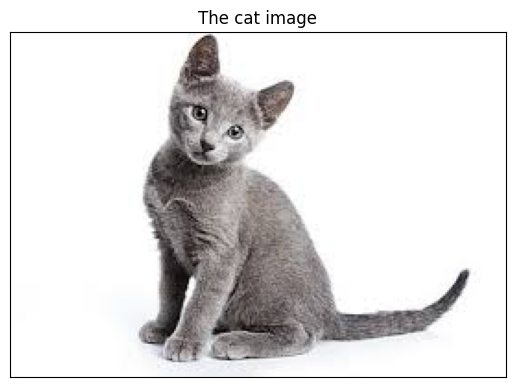

In [3]:
# Import the 'io' module from scikit-image.
# It provides functions for reading and writing images.
from skimage import io

# Import pyplot from Matplotlib for displaying and plotting images.
from matplotlib import pyplot as plt


# Read the image 'graycat.jpeg' from the 'images' folder.
# The image is stored in the variable 'cat'.
cat = io.imread('images/graycat.jpeg')


# Display the image.
plt.imshow(cat)

# Add a title above the image.
plt.title('The cat image')

# Remove the numbers/tick marks from the x-axis.
plt.xticks([])

# Remove the numbers/tick marks from the y-axis.
plt.yticks([])

# Alternative way to remove both axes and their ticks:
# plt.axis('off')


# Display the figure.
plt.show()

### Questions

1. **Is the image a grayscale image or a color image?**

2. **If the image is a color image, convert it to a grayscale image.**

   * What command is used to convert an RGB image to grayscale?
   * Where can you find this command in the code/documentation?

3. **After converting the image to grayscale, did any of its properties change?**

   * Did the **data type** change?
   * Did the **pixel value range** change?
   * Did the **image dimensions (shape)** change?
   * What other properties, if any, were affected?


In [4]:
# Check the dimensions of the image
print("Image dimensions:", cat.shape)

# Check the data type of the pixel values
print("Data type:", cat.dtype)

# Check the maximum pixel value
print("Maximum pixel value:", cat.max())

# Check the minimum pixel value
print("Minimum pixel value:", cat.min())

Image dimensions: (187, 269, 3)
Data type: uint8
Maximum pixel value: 255
Minimum pixel value: 0


Type: float64 min: 0.0008333333333333333 max: 1.0


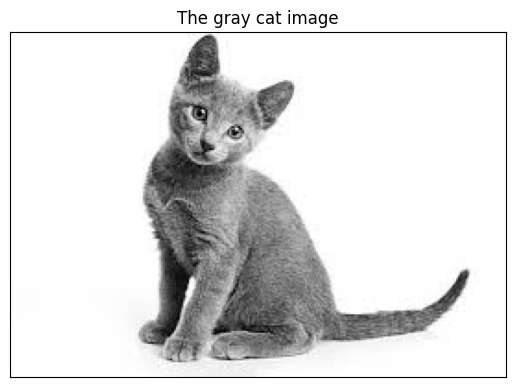

In [5]:
# Import the rgb2gray function from scikit-image.
# This function converts an RGB (color) image into a grayscale image.
from skimage.color import rgb2gray

# Convert the color image 'cat' to a grayscale image.
# The resulting grayscale image is stored in 'cat_gray'.
cat_gray = rgb2gray(cat)

# Visualize the grayscale image.
# The 'gray' colormap displays the image using shades of gray.
plt.imshow(cat_gray, cmap='gray')

# Add a title to the image.
plt.title('The gray cat image')

# Remove the tick marks and numbers from the x-axis.
plt.xticks([])

# Remove the tick marks and numbers from the y-axis.
plt.yticks([])

# Print some properties of the grayscale image:
# - dtype: the data type of the pixel values
# - min: the minimum pixel value
# - max: the maximum pixel value
print(
    'Type:', cat_gray.dtype,
    'min:', cat_gray.min(),
    'max:', cat_gray.max()
)

# Display the image.
plt.show()

### **Casting the Image to Floating-Point**

When processing an image, it can be useful to convert its pixel values to a floating-point data type.

However, we may not always need **64-bit precision**. To reduce memory usage, we can consider using a lower-precision type such as **`float16`**.

**Question:**
What are the different ways to cast an image to a floating-point data type in Python?

In [6]:
# Display the properties of the grayscale image:
# - shape: dimensions of the image
# - dtype: data type of the pixel values
# - min: minimum pixel value
# - max: maximum pixel value
print(
    'Graylevel image:',
    cat_gray.shape,
    cat_gray.dtype,
    cat_gray.min(),
    cat_gray.max()
)

# Convert the image to 16-bit floating-point numbers.
# IMPORTANT: astype() creates a NEW array; it does not modify cat_gray itself.
cat_gray.astype('float16')

# Check the properties of cat_gray again.
# The properties remain unchanged because we did not save
# the result of astype() into a variable.
print(
    cat_gray.shape,
    cat_gray.dtype,
    cat_gray.min(),
    cat_gray.max()
)

# Convert cat_gray to float16 and store the result in a new variable called catf.
catf = cat_gray.astype('float16')

# Check the properties of the new float16 image.
print(
    catf.shape,
    catf.dtype,
    catf.min(),
    catf.max()
)

Graylevel image: (187, 269) float64 0.0008333333333333333 1.0
(187, 269) float64 0.0008333333333333333 1.0
(187, 269) float16 0.0008335 1.0


### Explanation

`cat_gray.astype('float16')` creates a **new temporary copy** of `cat_gray` with the `float16` data type. Since the result is not assigned to a variable, the new array is not saved, and `cat_gray` remains unchanged.

To keep the converted image, we need to assign the result to a variable:

```python
catf = cat_gray.astype('float16')
```


**Another way to convert an image to a floating-point representation** is to use
`img_as_float()` from **scikit-image**. Unlike `astype()`, this function is
specifically designed for image data and appropriately handles the pixel-value
range.

In [7]:
# Import the img_as_float function from scikit-image.
from skimage import img_as_float

# Convert the grayscale image to a floating-point image.
# img_as_float() returns a new image with an appropriate floating-point
# data type and pixel-value range for image processing.
catfl = img_as_float(cat_gray)

# Display the main properties of the converted image:
# - Shape: dimensions of the image
# - Data type: type used to store the pixel values
# - Minimum: minimum pixel value
# - Maximum: maximum pixel value
print("Image shape:", catfl.shape)
print("Data type:", catfl.dtype)
print("Minimum pixel value:", catfl.min())
print("Maximum pixel value:", catfl.max())

Image shape: (187, 269)
Data type: float64
Minimum pixel value: 0.0008333333333333333
Maximum pixel value: 1.0


**Let's visualize one line (row) of the image as a topographic profile. Then, try to identify which features of the graph correspond to different regions of the image.**


Cat dtype: float64
Min: 0.0008333333333333333
Max: 1.0
Average: 0.8636780468400707


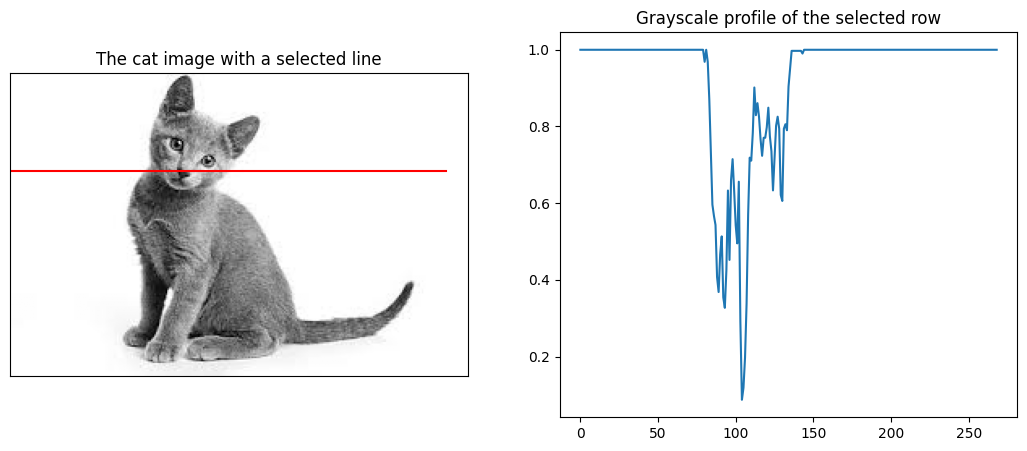

In [8]:
# Select the row of the image that we want to analyze.
row = 60

# Display some basic properties of the grayscale image.
print("Cat dtype:", cat_gray.dtype)
print("Min:", cat_gray.min())
print("Max:", cat_gray.max())
print("Average:", cat_gray.mean())

# Create a figure with two side-by-side plots.
fig, ax = plt.subplots(ncols=2, figsize=(13, 5))

# Display the grayscale cat image.
ax[0].imshow(cat_gray, cmap='gray')

# Draw a red horizontal line to show the selected row.
ax[0].plot(
    [0, cat_gray.shape[1]],
    [row, row],
    color='red'
)

# Add a title to the image.
ax[0].set_title('The cat image with a selected line')

# Hide the x- and y-axis tick marks.
ax[0].set_xticks([])
ax[0].set_yticks([])

# Extract the selected row from the image.
# Each value represents the grayscale intensity of one pixel.
grey_profile = cat_gray[row]

# Plot the grayscale values of the selected row as a function.
# The x-axis represents the pixel position.
# The y-axis represents the grayscale intensity.
ax[1].plot(grey_profile)

# Add a title to the profile plot.
ax[1].set_title('Grayscale profile of the selected row')

plt.show()

**Next, we invert the grayscale values of the cat image.** The expression `1 - cat_gray` replaces each pixel value with its inverse. For example, a pixel value of `0` becomes `1`, and a value of `1` becomes `0`. We then modify one row of the inverted image and display the result to visualize the effect of this transformation.


Cat dtype: float64
Cat min: 0.0008333333333333333
Cat max: 1.0
Cat inverted dtype: float64
Cat inverted min: 0.0
Cat inverted max: 1.0
Cat inverted Average: 0.14134508677414864


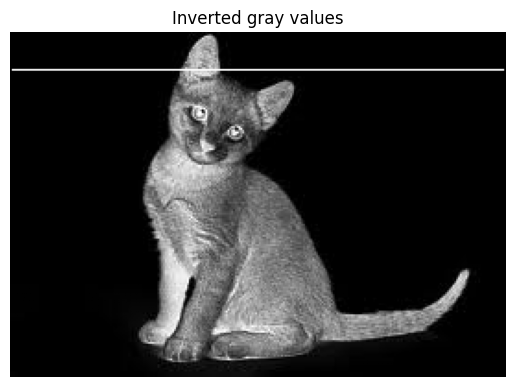

In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Invert the grayscale values of the image.
# A pixel value of 0 becomes 1, 1 becomes 0, and intermediate
# values are also inverted (for example, 0.2 becomes 0.8).
catinv = 1 - cat_gray

# Change the pixel values in row 20 to 1, except for the first
# and last pixel.
# This creates a horizontal white line in the inverted image.
catinv[20, 1:catinv.shape[1] - 1] = 1

# Display the properties of the original grayscale image.
print("Cat dtype:", cat_gray.dtype)
print("Cat min:", cat_gray.min())
print("Cat max:", cat_gray.max())

# Display the properties of the inverted image.
print("Cat inverted dtype:", catinv.dtype)
print("Cat inverted min:", catinv.min())
print("Cat inverted max:", catinv.max())
print("Cat inverted Average:", catinv.mean())

# Display the inverted image using a grayscale colormap.
plt.imshow(catinv, cmap='gray')

# Add a title to the image.
plt.title('Inverted gray values')

# Hide the axes.
plt.axis('off')

# Display the figure.
plt.show()

### **Float-to-Integer Conversion**

Before continuing, let's convert the (non-inverted) image from a floating-point representation back to an integer data type.


Original image
Shape: (187, 269)
Data type: float64
Minimum pixel value: 0.0008333333333333333
Maximum pixel value: 1.0
Average pixel value: 0.8636780468400707

Converted image
Shape: (187, 269)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Average pixel value: 220.07782836013757


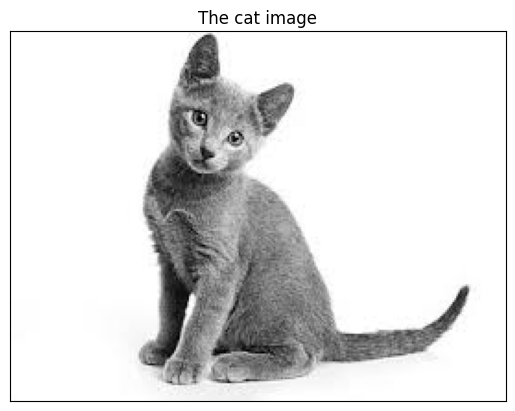

In [10]:
# Import the rescale function from scikit-image.
# (It is not used in this cell, but can be used later to resize images.)
from skimage.transform import rescale

# Display the properties of the grayscale image.
print("Original image")
print("Shape:", cat_gray.shape)
print("Data type:", cat_gray.dtype)
print("Minimum pixel value:", cat_gray.min())
print("Maximum pixel value:", cat_gray.max())
print("Average pixel value:", cat_gray.mean())

# Convert the pixel values from the range [0, 1] to [0, 255].
cati = 255.0 * cat_gray

# Convert the image to 8-bit unsigned integers.
# Pixel values are now stored as integers between 0 and 255.
catint = cati.astype('uint8')

# Display the properties of the converted image.
print("\nConverted image")
print("Shape:", catint.shape)
print("Data type:", catint.dtype)
print("Minimum pixel value:", catint.min())
print("Maximum pixel value:", catint.max())
print("Average pixel value:", catint.mean())

# Visualize the original grayscale image.
plt.imshow(cat_gray, cmap='gray', aspect='auto')

# Add a title.
plt.title('The cat image')

# Hide the axis tick marks.
plt.xticks([])
plt.yticks([])

# Display the figure.
plt.show()

## Spatial Resolution

### Rescale, Resize, and Downscale

Scikit-image provides several functions for changing the size of an image:

* **`rescale`** resizes an image using a scaling factor. The factor can be a single value applied to all dimensions or a different value for each axis.

* **`resize`** also changes the size of an image, but instead of specifying a scaling factor, you directly specify the desired output shape.

* **`downscale_local_mean`** reduces the size of an image by integer factors. It computes the average value within each block of pixels, producing a smaller image while preserving overall intensity information.

> **Important:** When reducing the size of an image (downsampling), it is recommended to apply Gaussian smoothing before rescaling or resizing to prevent aliasing artifacts. In scikit-image, this can be done using the `anti_aliasing` and `anti_aliasing_sigma` parameters available in the `rescale` and `resize` functions.

**Exercise:** Given the cat image, increase its spatial resolution by a factor of two (i.e., double the number of pixels along each dimension).



### Exercise: Spatial Resolution

Given the cat image:

1. Increase its spatial resolution by a factor of 2 (upsampling).
2. Decrease its spatial resolution by a factor of 3 (downsampling).
3. Visualize the resulting images and compare them with the original image.
4. Discuss how these operations affect image quality, level of detail, and pixelation.


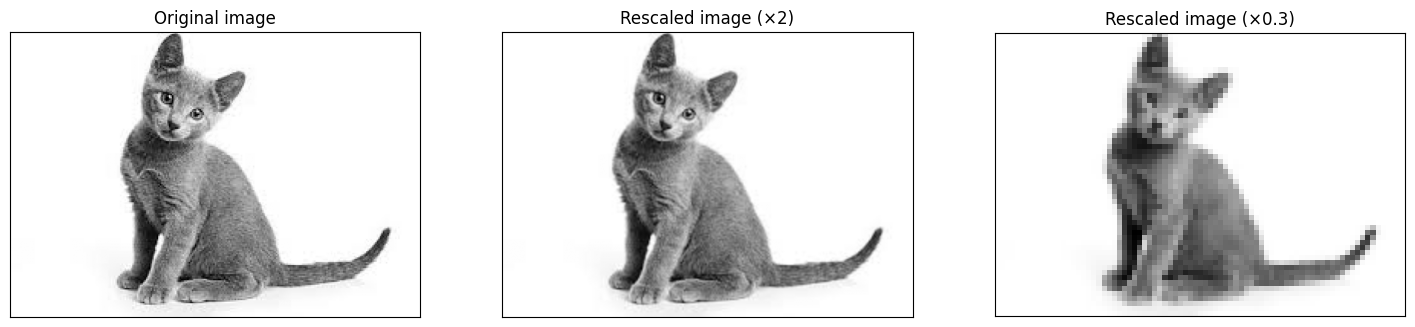

Original image
Shape: (187, 269)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Average pixel value: 220.07782836013757

Upsampled image (×2)
Shape: (374, 538)
Data type: float64
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Average pixel value: 0.8630478613328716

Downsampled image (×0.3)
Shape: (56, 81)
Data type: float64
Minimum pixel value: 0.07613863641708088
Maximum pixel value: 1.0
Average pixel value: 0.8630979473778341


In [11]:
from skimage.transform import rescale

# Increase the spatial resolution of the image by a factor of 2.
# The output image will have twice as many pixels along each dimension.
cat2 = rescale(catint, 2)

# Decrease the spatial resolution of the image to 30% of its original size.
# anti_aliasing=True applies smoothing before downsampling
# to reduce aliasing artifacts.
cat3 = rescale(catint, 0.3, anti_aliasing=True)

# Create a figure to display the three images side by side.
fig = plt.figure(figsize=(18, 9))

# Display the original image.
fig.add_subplot(1, 3, 1)
plt.imshow(catint, cmap='gray')
plt.title('Original image')
plt.xticks([])
plt.yticks([])

# Display the upsampled image.
fig.add_subplot(1, 3, 2)
plt.imshow(cat2, cmap='gray')
plt.title('Rescaled image (×2)')
plt.xticks([])
plt.yticks([])

# Display the downsampled image.
fig.add_subplot(1, 3, 3)
plt.imshow(cat3, cmap='gray')
plt.title('Rescaled image (×0.3)')
plt.xticks([])
plt.yticks([])

# Display the figure.
plt.show()

# Display the properties of the original image.
print("Original image")
print("Shape:", catint.shape)
print("Data type:", catint.dtype)
print("Minimum pixel value:", catint.min())
print("Maximum pixel value:", catint.max())
print("Average pixel value:", catint.mean())

# Display the properties of the upsampled image.
print("\nUpsampled image (×2)")
print("Shape:", cat2.shape)
print("Data type:", cat2.dtype)
print("Minimum pixel value:", cat2.min())
print("Maximum pixel value:", cat2.max())
print("Average pixel value:", cat2.mean())

# Display the properties of the downsampled image.
print("\nDownsampled image (×0.3)")
print("Shape:", cat3.shape)
print("Data type:", cat3.dtype)
print("Minimum pixel value:", cat3.min())
print("Maximum pixel value:", cat3.max())
print("Average pixel value:", cat3.mean())

### **Photometric Resolution**

Photometric resolution depends on the number of gray levels used to represent an image.

Next, let's check the minimum and maximum pixel values of the image to determine its intensity range.


In [12]:
# Display the maximum and minimum pixel values of the image.
print("Maximum pixel value:", catint.max())
print("Minimum pixel value:", catint.min())

Maximum pixel value: 255
Minimum pixel value: 0


**Reduce the resolution 10 and 25 times**

In the following code, we examine the data type and pixel-value range of the original image. We then divide the pixel values by 10 and 25 to observe how these operations affect the data type and minimum and maximum pixel values.

In [13]:
# Display the properties of the original integer image.
print("Catint data type:", catint.dtype)
print("Minimum pixel value:", catint.min())
print("Maximum pixel value:", catint.max())


# Divide the normalized pixel values by 10.
cat10 = catint / 10

# Display the properties of the resulting image.
print("\nCat10 data type:", cat10.dtype)
print("Minimum pixel value:", cat10.min())
print("Maximum pixel value:", cat10.max())

# Divide the normalized pixel values by 25.
cat25 = catint / 25

# Display the properties of the resulting image.
print("\nCat25 data type:", cat25.dtype)
print("Minimum pixel value:", cat25.min())
print("Maximum pixel value:", cat25.max())

Catint data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255

Cat10 data type: float64
Minimum pixel value: 0.0
Maximum pixel value: 25.5

Cat25 data type: float64
Minimum pixel value: 0.0
Maximum pixel value: 10.2


**Effect of Pixel Value Reduction**

In the following code, we convert the modified images back to **8-bit integer format** and visualize the results. We compare the original image with images obtained by dividing the pixel values by **10 and 25**, and examine how these operations affect the pixel-value range and image appearance.


Cat10 - Minimum pixel value: 0
Cat10 - Maximum pixel value: 25

Cat25 - Minimum pixel value: 0
Cat25 - Maximum pixel value: 10


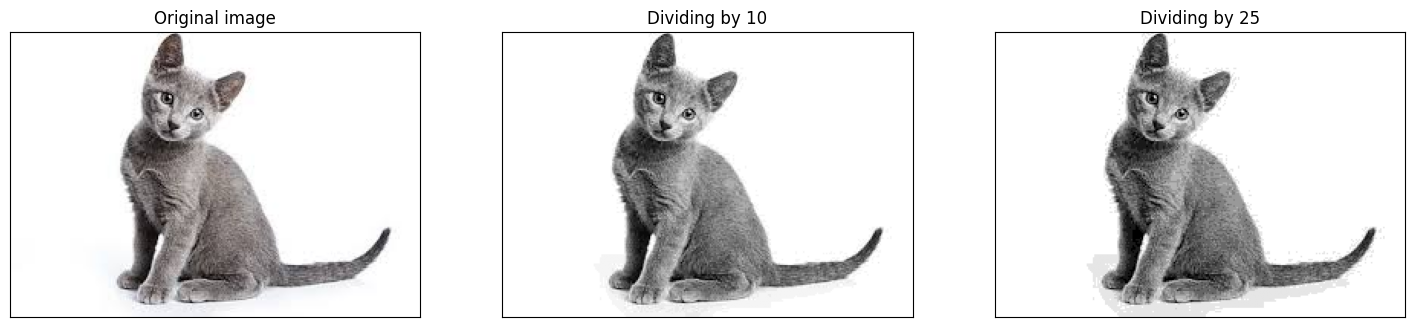

In [14]:
# Convert the pixel values of cat10 to unsigned 8-bit integers.
cat10 = cat10.astype("uint8")

# Convert the pixel values of cat25 to unsigned 8-bit integers.
cat25 = cat25.astype("uint8")

# Create a figure to display the three images side by side.
fig = plt.figure(figsize=(18, 9))

# Display the original image.
fig.add_subplot(1, 3, 1)
plt.imshow(cat, cmap='gray', vmin=0, vmax=255)
plt.title('Original image')
plt.xticks([])
plt.yticks([])


# Display the image after dividing the pixel values by 10.
fig.add_subplot(1, 3, 2)
plt.imshow(cat10, cmap='gray')
plt.title('Dividing by 10')
plt.xticks([])
plt.yticks([])

# Display the image after dividing the pixel values by 25.
fig.add_subplot(1, 3, 3)
plt.imshow(cat25, cmap='gray')
plt.title('Dividing by 25')
plt.xticks([])
plt.yticks([])

# Display the minimum and maximum pixel values of cat10.
print("Cat10 - Minimum pixel value:", cat10.min())
print("Cat10 - Maximum pixel value:", cat10.max())

# Display the minimum and maximum pixel values of cat25.
print("\nCat25 - Minimum pixel value:", cat25.min())
print("Cat25 - Maximum pixel value:", cat25.max())


**Fixed Intensity Range Visualization**

In the following code, the three images are displayed using the same fixed intensity range, from **0 to 255**. This allows us to compare the images using a consistent grayscale scale and observe how dividing the pixel values by 10 and 25 affects their appearance.

The parameters **`vmin`** and **`vmax`** define the minimum and maximum values of the intensity range used to display the image.

In this example, `vmin=0` and `vmax=255` set a fixed grayscale range from **0 (black) to 255 (white)**. Using the same range for all three images allows us to make a direct visual comparison without Matplotlib automatically adjusting the contrast of each image.



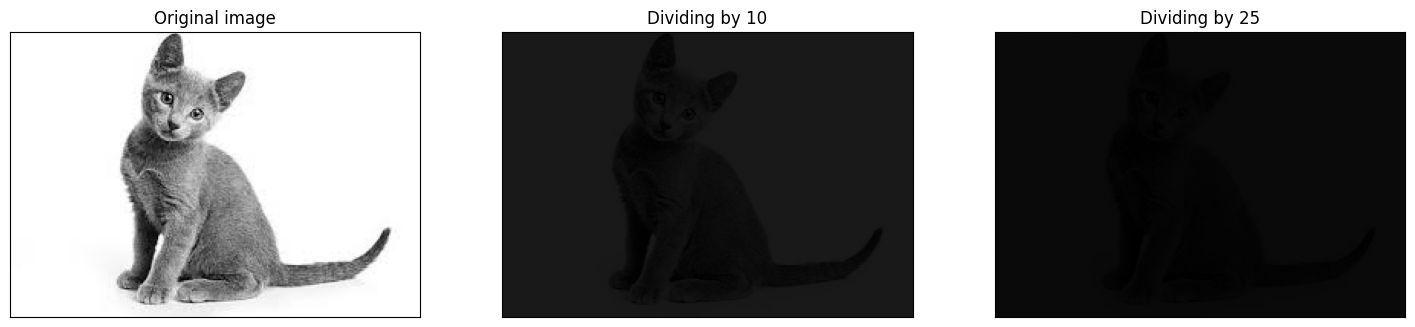

In [15]:
# Create a figure to display the three images side by side.
fig = plt.figure(figsize=(18, 8))

# Display the original image using a fixed intensity range from 0 to 255.
fig.add_subplot(1, 3, 1)
plt.imshow(catint, cmap='gray', vmin=0, vmax=255)
plt.title('Original image')
plt.xticks([])
plt.yticks([])


# Display the image after dividing the pixel values by 10.
# The same intensity range (0–255) is used for comparison.
fig.add_subplot(1, 3, 2)
plt.imshow(cat10, cmap='gray', vmin=0, vmax=255)
plt.title('Dividing by 10')
plt.xticks([])
plt.yticks([])


# Display the image after dividing the pixel values by 25.
# The same intensity range (0–255) is used for comparison.
fig.add_subplot(1, 3, 3)
plt.imshow(cat25, cmap='gray', vmin=0, vmax=255)
plt.title('Dividing by 25')
plt.xticks([])
plt.yticks([])
plt.show()

Next, we determine how many **different pixel values (intensity levels)** are present in each image. We use `np.unique()` to identify the unique pixel values and then count them to compare how dividing the pixel values by **10 and 25** affects the number of available intensity levels.


In [16]:
import numpy as np

# Find all unique pixel values in the image.
# This shows the different intensity values present in catint.
print(np.unique(catint))

# Count the number of different pixel values in the image.
# The shape indicates how many unique intensity levels are present.
print(np.unique(catint).shape)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

In [17]:
# Find all unique pixel values in cat10.
# This shows the different intensity values present after dividing
# the original image pixel values by 10.
print(np.unique(cat10))

# Count the number of different pixel values in cat10.
# The shape indicates how many unique intensity levels are present.
print(np.unique(cat10).shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
(26,)


In [18]:
# Find all unique pixel values in cat25.
# This shows the different intensity values present after dividing
# the original image pixel values by 25.
print(np.unique(cat25))

# Count the number of different pixel values in cat25.
# The shape indicates how many unique intensity levels are present.
print(np.unique(cat25).shape)

[ 0  1  2  3  4  5  6  7  8  9 10]
(11,)


### **Histograms**

A **histogram** shows the distribution of pixel intensity values in an image. It tells us how frequently each intensity level occurs.

For integer images, each integer intensity value is assigned to its own bin. This avoids unnecessary rebinning and preserves the image's intensity resolution.

The histogram is computed using the **flattened image**, meaning that all pixels are considered as a single one-dimensional sequence.

The number of **bins** determines how the pixel intensity range is divided in a histogram. A smaller number of bins produces fewer and wider bars, while a larger number of bins produces more and narrower bars.

> **For color images**, the histogram should be computed separately for each color channel (for example, red, green, and blue) to obtain an individual histogram for each channel.

Let's compare the histogram of the cat image using **10 bins** and **50 bins**.

> `.ravel()` flattens the image into a one-dimensional array. This is useful for plotting a histogram because the histogram considers all pixels as a single collection of intensity values.


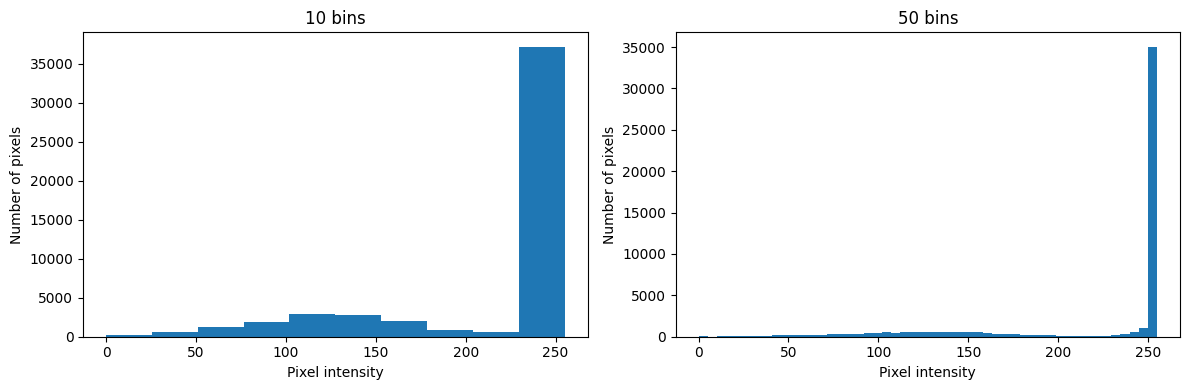

In [19]:
# Create a figure with two side-by-side plots.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Display the histogram using 10 bins.
ax[0].hist(catint.ravel(), bins=10)
ax[0].set_title("10 bins")
ax[0].set_xlabel("Pixel intensity")
ax[0].set_ylabel("Number of pixels")

# Display the histogram using 50 bins.
ax[1].hist(catint.ravel(), bins=50)
ax[1].set_title("50 bins")
ax[1].set_xlabel("Pixel intensity")
ax[1].set_ylabel("Number of pixels")

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

Next, we compute the **histogram** of the original image and the images obtained by dividing the pixel values by 10 and 25. We also compute the histogram of an **inverted version of `cat25`** to observe how the intensity distribution changes after inversion.

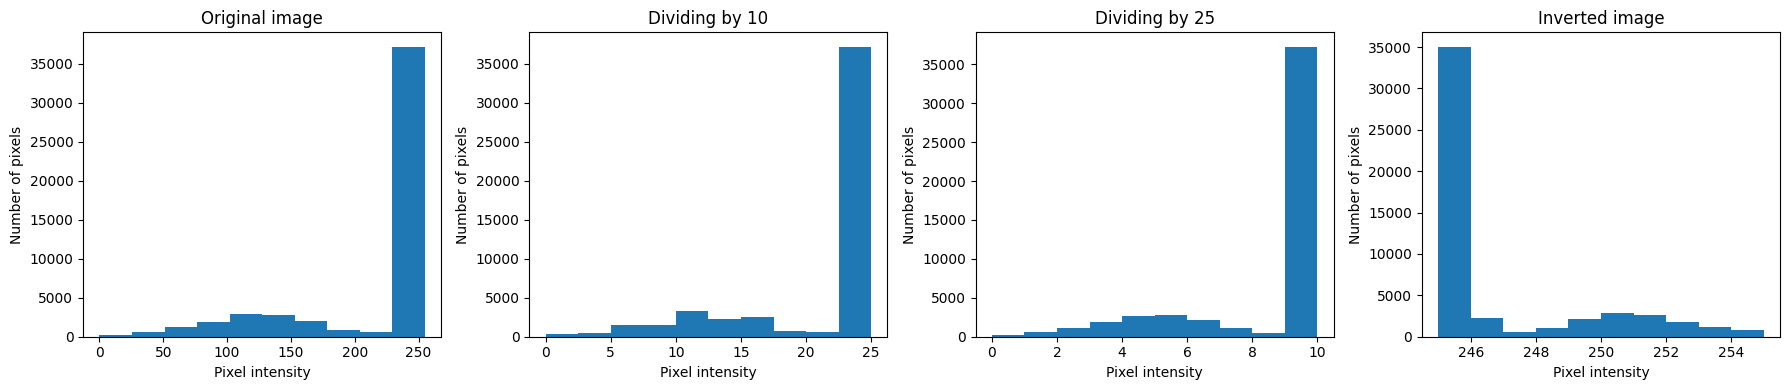

In [20]:
# Create a figure with four side-by-side histograms.
fig, ax = plt.subplots(1, 4, figsize=(18, 4))

# Display the histogram of the original image.
ax[0].hist(catint.ravel(), bins=10)
ax[0].set_title("Original image")
ax[0].set_xlabel("Pixel intensity")
ax[0].set_ylabel("Number of pixels")

# Display the histogram of the image after dividing the pixel values by 10.
ax[1].hist(cat10.ravel(), bins=10)
ax[1].set_title("Dividing by 10")
ax[1].set_xlabel("Pixel intensity")
ax[1].set_ylabel("Number of pixels")

# Display the histogram of the image after dividing the pixel values by 25.
ax[2].hist(cat25.ravel(), bins=10)
ax[2].set_title("Dividing by 25")
ax[2].set_xlabel("Pixel intensity")
ax[2].set_ylabel("Number of pixels")

# Display the histogram of the inverted cat25 image.
ax[3].hist((255 - cat25).ravel(), bins=10)
ax[3].set_title("Inverted image")
ax[3].set_xlabel("Pixel intensity")
ax[3].set_ylabel("Number of pixels")

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

### **Histogram with scikit-image**

Scikit-image also provides the `histogram()` function to compute an image histogram. Unlike `plt.hist()`, it returns the **histogram values** and the corresponding **bin centers**, which can be useful when we want to work with the histogram data directly.


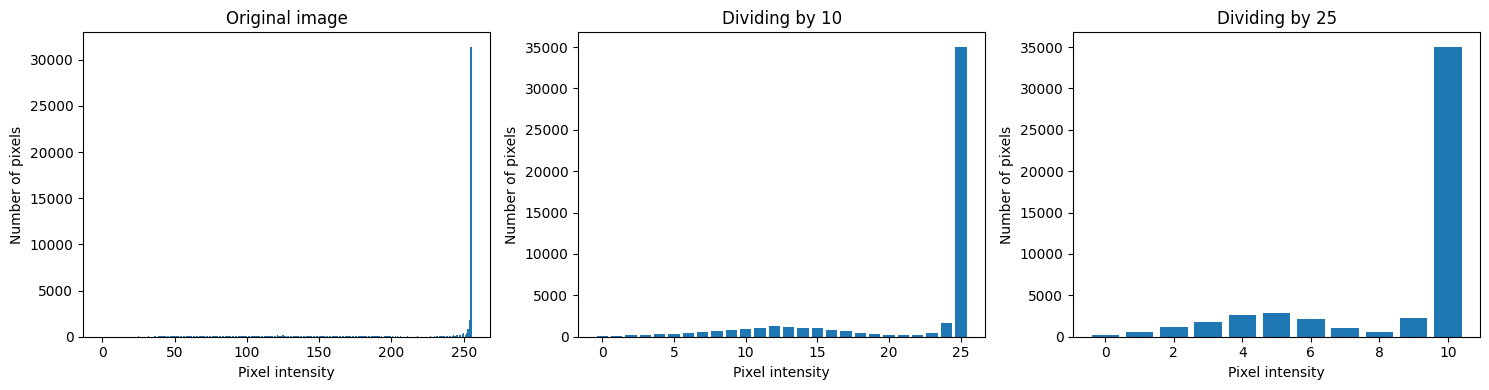

In [21]:
# Import the histogram function from scikit-image.
from skimage.exposure import histogram

# Define the number of bins for the histograms.
numberOfBins = 50

# Compute the histograms of the three images.
hist, bin_centers = histogram(catint, nbins=numberOfBins)
hist10, bin_centers10 = histogram(cat10, nbins=numberOfBins)
hist25, bin_centers25 = histogram(cat25, nbins=numberOfBins)

# Create a figure with three side-by-side plots.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Display the histogram of the original image.
ax[0].bar(bin_centers, hist)
ax[0].set_title("Original image")
ax[0].set_xlabel("Pixel intensity")
ax[0].set_ylabel("Number of pixels")

# Display the histogram of cat10.
ax[1].bar(bin_centers10, hist10)
ax[1].set_title("Dividing by 10")
ax[1].set_xlabel("Pixel intensity")
ax[1].set_ylabel("Number of pixels")

# Display the histogram of cat25.
ax[2].bar(bin_centers25, hist25)
ax[2].set_title("Dividing by 25")
ax[2].set_xlabel("Pixel intensity")
ax[2].set_ylabel("Number of pixels")

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

> For integer images, `skimage.exposure.histogram()` handles pixel values differently from floating-point images. Therefore, setting `nbins=50` does not necessarily produce exactly 50 bars. To make `nbins` control the number of bins, **convert the image to a floating-point representation before computing the histogram**, as illustrated next.


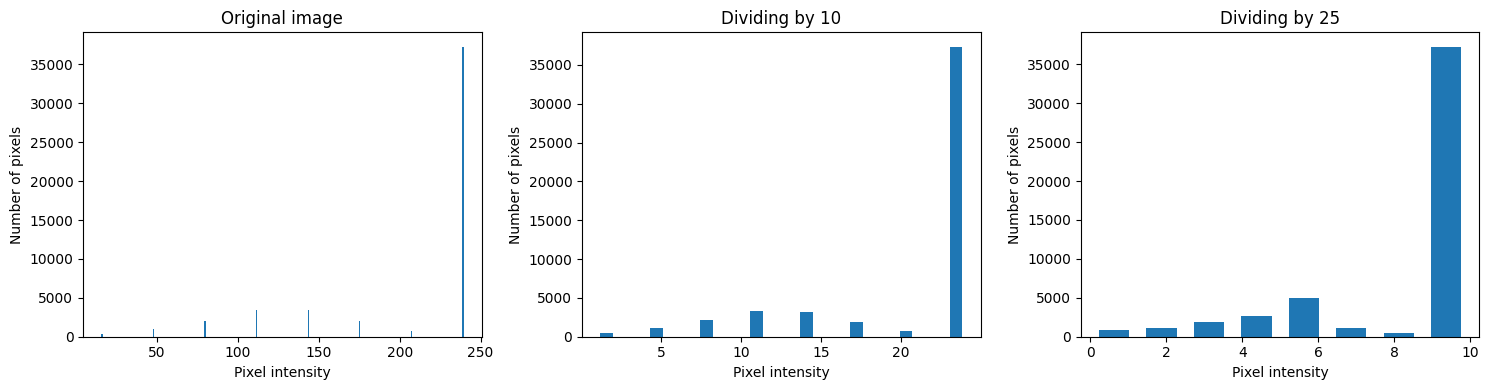

In [22]:
# Import the histogram function from scikit-image.
from skimage.exposure import histogram

# Convert the images to floating-point representation.
catint_float = catint.astype(float)
cat10_float = cat10.astype(float)
cat25_float = cat25.astype(float)

# Define the number of bins for the histograms.
numberOfBins = 8

# Compute the histograms of the three images.
hist, bin_centers = histogram(catint_float, nbins=numberOfBins)
hist10, bin_centers10 = histogram(cat10_float, nbins=numberOfBins)
hist25, bin_centers25 = histogram(cat25_float, nbins=numberOfBins)

# Create a figure with three side-by-side plots.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Display the histogram of the original image.
ax[0].bar(bin_centers, hist)
ax[0].set_title("Original image")
ax[0].set_xlabel("Pixel intensity")
ax[0].set_ylabel("Number of pixels")

# Display the histogram of cat10.
ax[1].bar(bin_centers10, hist10)
ax[1].set_title("Dividing by 10")
ax[1].set_xlabel("Pixel intensity")
ax[1].set_ylabel("Number of pixels")

# Display the histogram of cat25.
ax[2].bar(bin_centers25, hist25)
ax[2].set_title("Dividing by 25")
ax[2].set_xlabel("Pixel intensity")
ax[2].set_ylabel("Number of pixels")

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

Compute the image histogram using both **`skimage.exposure`** and **NumPy**. You may notice that the resulting histograms are not identical. 

> **Compare the outputs and investigate why they differ.**
> **Hint:** `skimage.exposure.histogram` reports **bin centers**, while `numpy.histogram` reports **bin edges**.
>
> For example, if the bin edges are:
>
> * **Bin 1:** edges **0** and **25** → interval **[0, 25)**, center = **12.5**
> * **Bin 2:** edges **25** and **50** → interval **[25, 50)**, center = **37.5**
> * **Bin 3:** edges **50** and **75** → interval **[50, 75)**, center = **62.5**
> * **Bin 4:** edges **75** and **100** → interval **[75, 100]**, center = **87.5**
>
> Here, the **edges** define the boundaries of each interval, while the **center** is the midpoint of the interval. Investigate the difference between the two implementations and explain why they produce different results. 



In [23]:
# Compute histogram using skimage.exposure.histogram
# Returns:
#   hst[0] -> counts (number of pixels in each bin)
#   hst[1] -> bin centers
hst = histogram(cat_gray.astype('float'), nbins=4)  # skimage.exposure

# Compute histogram using numpy.histogram
# Returns:
#   hstnp[0] -> counts (number of pixels in each bin)
#   hstnp[1] -> bin edges
hstnp = np.histogram(cat_gray.astype('float'), bins=4)  # NumPy

# Display counts and bin centers from skimage
print(hst[0], hst[1])

# Display counts and bin edges from NumPy
print(hstnp[0], hstnp[1])


[ 1353  5439  5436 38075] [0.12572917 0.37552083 0.6253125  0.87510417]
[ 1353  5439  5436 38075] [8.33333333e-04 2.50625000e-01 5.00416667e-01 7.50208333e-01
 1.00000000e+00]


### **Computing the Histogram of an RGB Image**

The image `cat` below is an **RGB color image**, where each pixel contains three intensity values: **Red (R)**, **Green (G)**, and **Blue (B)**.

We will compute and analyze the **histogram for each color channel separately**. First, we visualize the three channels as grayscale images to examine their individual intensity distributions.

(187, 269, 3)


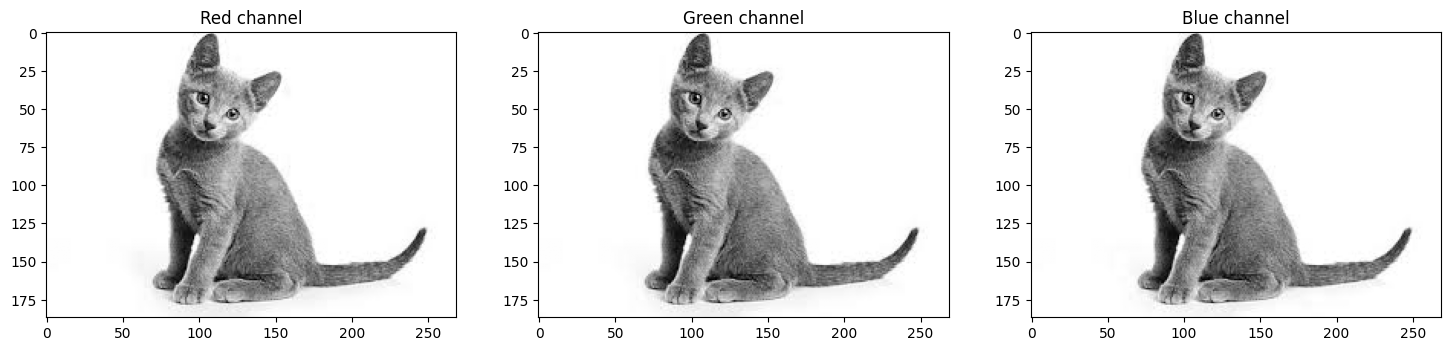

In [24]:
# Display the dimensions of the RGB image.
# The shape is (height, width, 3), where the last dimension
# represents the Red, Green, and Blue channels.
print(cat.shape)

# Create a figure to display the three channels side by side.
fig = plt.figure(figsize=(18, 9))

# Red channel: channel 0
fig.add_subplot(1, 3, 1)
plt.imshow(cat[:, :, 0], cmap='gray')
plt.title('Red channel')

# Green channel: channel 1
fig.add_subplot(1, 3, 2)
plt.imshow(cat[:, :, 1], cmap='gray')
plt.title('Green channel')

# Blue channel: channel 2
fig.add_subplot(1, 3, 3)
plt.imshow(cat[:, :, 2], cmap='gray')
plt.title('Blue channel')
plt.show()

> First, we use **`plt.hist()`** to compute and plot the histogram of each RGB channel. We use **10 bins** to group the pixel intensity values into 10 ranges. The three histograms are displayed **side by side**, allowing us to compare the intensity distributions of the Red, Green, and Blue channels.

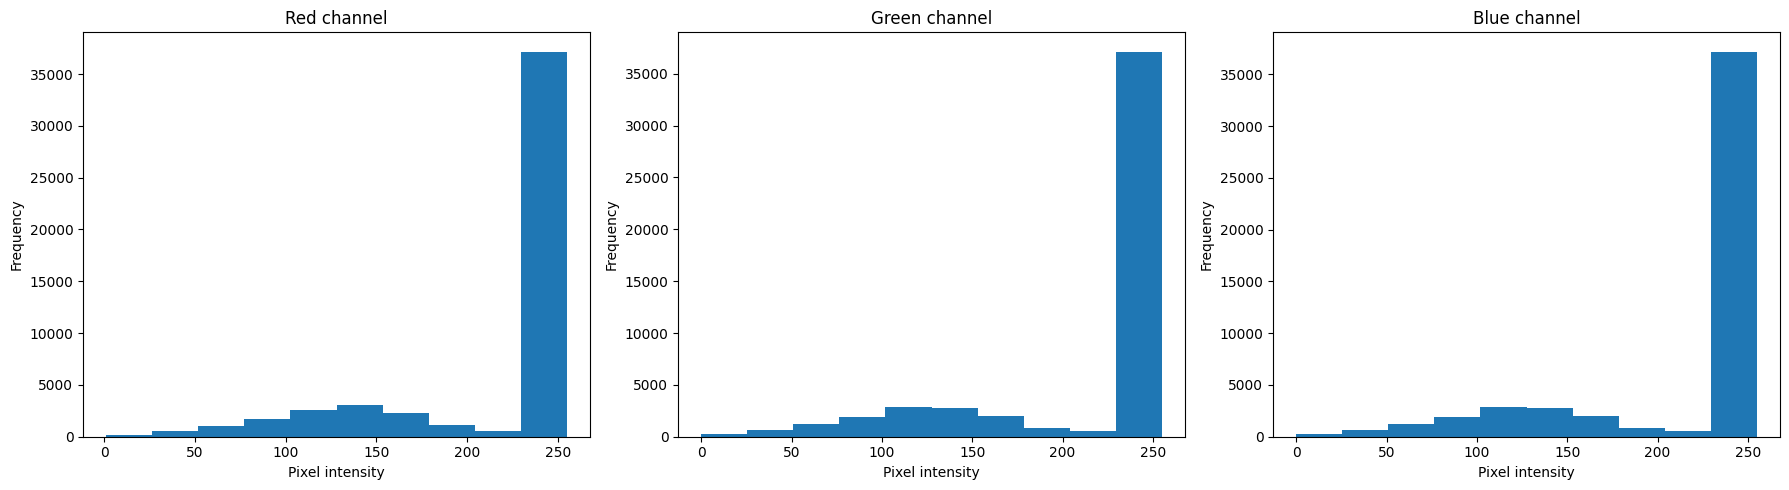

In [25]:
# Create a figure with three subplots, one for each RGB channel.
fig = plt.figure(figsize=(18, 5))

# Red channel histogram
fig.add_subplot(1, 3, 1)
plt.hist(cat[:, :, 0].ravel(), bins=10)
plt.title('Red channel')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')

# Green channel histogram
fig.add_subplot(1, 3, 2)
plt.hist(cat[:, :, 1].ravel(), bins=10)
plt.title('Green channel')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')

# Blue channel histogram
fig.add_subplot(1, 3, 3)
plt.hist(cat[:, :, 2].ravel(), bins=10)
plt.title('Blue channel')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')

plt.tight_layout()

> Next, we use **`skimage.exposure.histogram()`** to compute the histograms. This allows us to compare the histogram computed by `histogram()` with the one generated by `plt.hist()`.

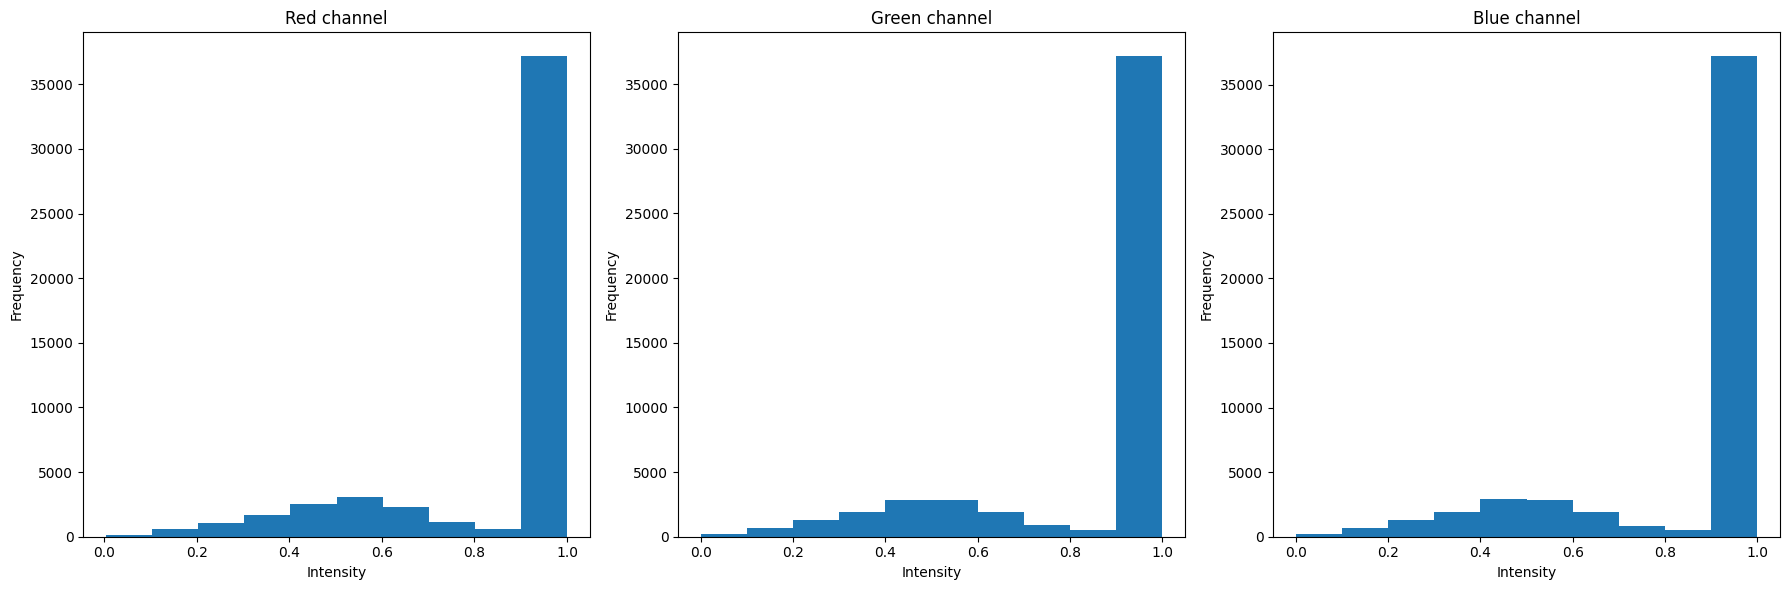

In [26]:
numberOfBins = 10

# Compute the histogram for each RGB channel
hst_r, bins_r = histogram(img_as_float(cat[:, :, 0]), nbins=numberOfBins)
hst_g, bins_g = histogram(img_as_float(cat[:, :, 1]), nbins=numberOfBins)
hst_b, bins_b = histogram(img_as_float(cat[:, :, 2]), nbins=numberOfBins)

# Create a figure with three plots arranged side by side
fig = plt.figure(figsize=(18, 6))

# Red channel histogram
fig.add_subplot(1, 3, 1)
plt.bar(bins_r, hst_r, width=bins_r[1] - bins_r[0])
plt.title('Red channel')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

# Green channel histogram
fig.add_subplot(1, 3, 2)
plt.bar(bins_g, hst_g, width=bins_g[1] - bins_g[0])
plt.title('Green channel')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

# Blue channel histogram
fig.add_subplot(1, 3, 3)
plt.bar(bins_b, hst_b, width=bins_b[1] - bins_b[0])
plt.title('Blue channel')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

***

## **Convolution**

**Let's smooth an image**

To smooth an image, we can use a convolution with a smoothing kernel.

**What is a convolution?**

A convolution applies a kernel (or filter) to the input image. For each position in the image, the output value is computed as a weighted sum of neighboring input values.

Each value in result is $C_i = \sum_j{I_{i+j-k} W_j}$, where $W$ is the weights kernel, $j$ is the n-D spatial index over $W$, $I$ is the input and $k$ is the coordinate of the center of $W$, specified by origin in the input parameters.


<img src='images/2D_Convolution_Animation.gif'>

### Multi-dimensional convolution

We can perform a multi-dimensional convolution using:

```python
scipy.ndimage.convolve(input, weights, output=None, mode='reflect')
```

**Questions to consider:**

* How do we define a **mask (kernel)**?
* What types of masks or kernels can we use?
* How should we handle the **borders of the image**?

A simple case to understand is:

```python
mode='constant', cval=0.0
```

With this setting, values outside the boundaries of the input image are treated as a constant value, specified by `cval` (zero by default).

This is particularly useful for understanding what happens at the **image borders**, where the kernel extends beyond the edge of the input image. In these regions, the parts of the kernel that fall outside the image are effectively applied to the constant value rather than to actual image pixels.


In [27]:
# Define a 1 × 5 convolution mask (kernel).
# All five neighboring pixels initially have the same weight.
mask = np.array([[1, 1, 1, 1, 1]])

# Normalize the mask so that the sum of all weights is equal to 1.
# Why? This prevents the convolution from changing the overall
# brightness/intensity scale of the image.
mask = mask / np.sum(mask)

# Display the normalized mask.
print(mask)

[[0.2 0.2 0.2 0.2 0.2]]


In [28]:
# Import the multi-dimensional convolution function from SciPy.
from scipy.ndimage import convolve

# Apply the convolution to the image using the mask (kernel).
# 'mode=constant' means that pixels outside the image boundaries
# are treated as a constant value.
# 'cval=0.0' specifies that this constant value is 0.
cat_smooth = convolve(catint, mask, mode='constant', cval=0.0)

# The 'mode' parameter determines how the input array is extended
# beyond its boundaries. The default is 'reflect'.
#
# mode='constant':
#
#        k k k k
#        k b c k
#        k k k k
#
# Values outside the image (represented by 'k') are replaced by
# the constant value specified by 'cval'.
#
# For example, with cval=0.0, the image is conceptually extended
# with zeros beyond its borders.

### Visualizing the Smoothing Result

The following code displays the **original image** and the **smoothed image** side by side, allowing us to visually compare the effect of the convolution.


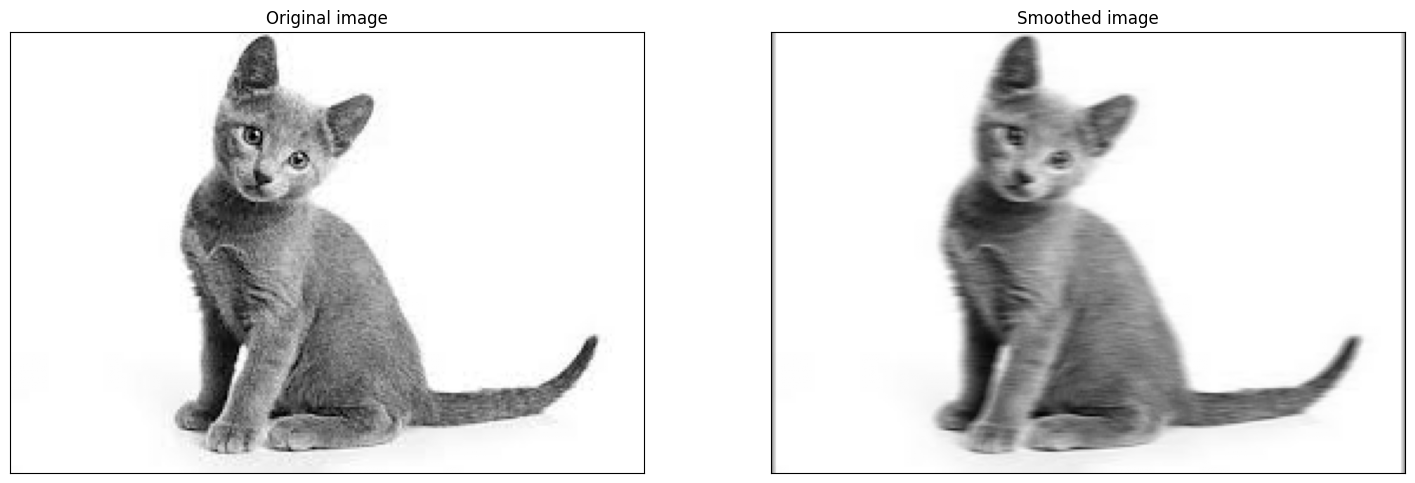

In [29]:
# Create a figure with two subplots displayed side by side.
fig = plt.figure(figsize=(18, 9))

# --- Original image ---
# Add the first subplot.
fig.add_subplot(1, 2, 1)

# Display the original image using a grayscale colormap.
plt.imshow(catint, cmap='gray')
plt.title('Original image')

# Hide the x- and y-axis tick marks for a cleaner visualization.
plt.xticks([])
plt.yticks([])

# --- Smoothed image ---
# Add the second subplot.
fig.add_subplot(1, 2, 2)

# Display the image after convolution and smoothing.
plt.imshow(cat_smooth, cmap='gray')
plt.title('Smoothed image')

# Hide the x- and y-axis tick marks.
plt.xticks([])
plt.yticks([])

# Display the figure.
plt.show()

### What would happen **if we don't normalize the mask**?

[[1 1 1 1 1]]


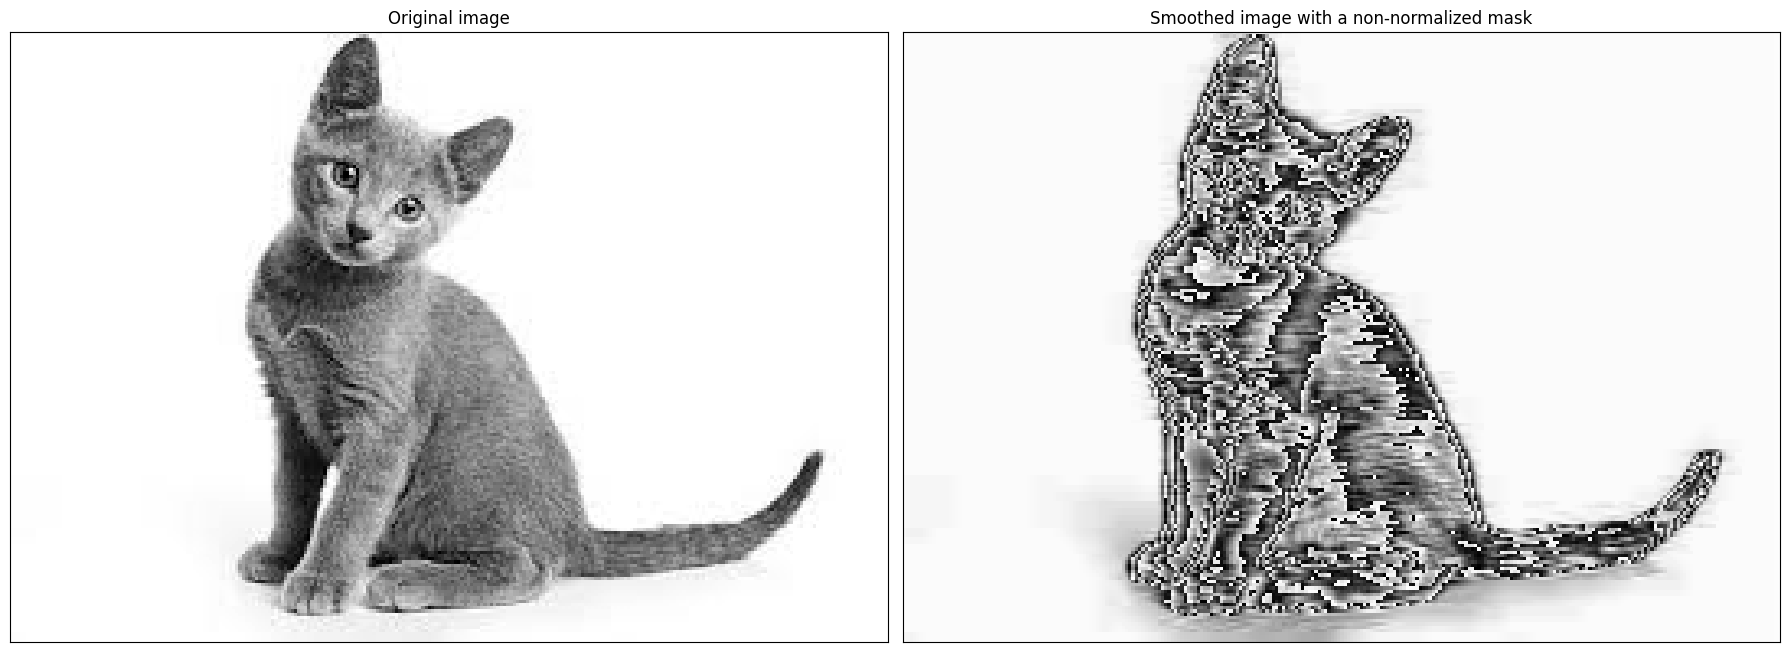

In [30]:
# Define a 1 × 5 convolution mask (kernel).
# Each element has a weight of 1.
mask = np.array([[1, 1, 1, 1, 1]])

# Display the mask.
print(mask)

# Apply the convolution using the non-normalized mask.
# Since the mask is not normalized, the sum of its weights is 5.
# This causes the output pixel values to be approximately 5 times
# larger than the corresponding local average.
#
# mode='constant' means that pixels outside the image boundaries
# are treated as a constant value.
# cval=0.0 specifies that this constant value is 0.
cat_smooth_no_norm = convolve(catint, mask, mode='constant', cval=0.0)


# Visualize the original and smoothed images side by side.
fig = plt.figure(figsize=(18, 9))

# Display the original image.
fig.add_subplot(1, 2, 1)
plt.imshow(catint, cmap='gray')
plt.title('Original image')
plt.xticks([])
plt.yticks([])

# Display the image smoothed using the non-normalized mask.
fig.add_subplot(1, 2, 2)
plt.imshow(cat_smooth_no_norm, cmap='gray')
plt.title('Smoothed image with a non-normalized mask')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

**Comparing Image Values**

Compare the **data type**, **minimum**, and **maximum** pixel values of the original and smoothed images.


In [31]:
print("Original image")
print(f"  dtype: {catint.dtype}")
print(f"  min:   {catint.min()}")
print(f"  max:   {catint.max()}")

print("\nSmoothed image (normalized mask)")
print(f"  dtype: {cat_smooth.dtype}")
print(f"  min:   {cat_smooth.min()}")
print(f"  max:   {cat_smooth.max()}")

print("\nSmoothed image (non-normalized mask)")
print(f"  dtype: {cat_smooth_no_norm.dtype}")
print(f"  min:   {cat_smooth_no_norm.min()}")
print(f"  max:   {cat_smooth_no_norm.max()}")

Original image
  dtype: uint8
  min:   0
  max:   255

Smoothed image (normalized mask)
  dtype: uint8
  min:   6
  max:   255

Smoothed image (non-normalized mask)
  dtype: uint8
  min:   0
  max:   255


Next, we apply the **non-normalized mask** to the image. The image is first converted to **float** to avoid integer overflow and allow floating-point output. We then visualize the result and compare the **data type, minimum, and maximum pixel values**.



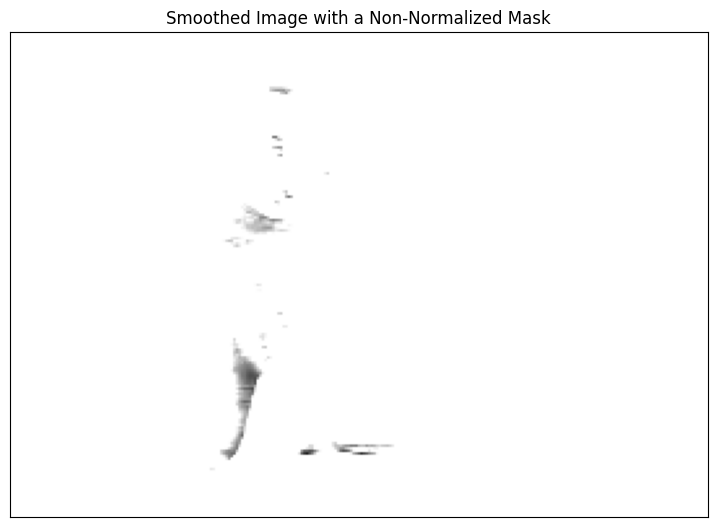

Original image:       dtype=uint8, min=0, max=255
Non-normalized image: dtype=float64, min=32.0, max=1275.0


In [32]:
# Apply the non-normalized mask to the image.
# Convert the image to float before convolution to avoid integer overflow
# and to allow the output to contain floating-point values.
cat_smooth_no_norm = convolve(
    catint.astype(float),
    mask,
    mode='constant',
    cval=0.0
)

# Visualize the image produced by the non-normalized convolution mask.
plt.figure(figsize=(9, 7))

# Display the smoothed image in grayscale.
# vmin=0 and vmax=255 set the display range to the standard
# 8-bit image intensity range.
plt.imshow(cat_smooth_no_norm, cmap='gray', vmin=0, vmax=255)

# Add a title to the displayed image.
plt.title('Smoothed Image with a Non-Normalized Mask')

# Remove the axis ticks for a cleaner image display.
plt.xticks([])
plt.yticks([])

plt.show()

# Compare the data type, minimum, and maximum pixel values
# of the original image and the smoothed image.
print(
    "Original image:       "
    f"dtype={catint.dtype}, "
    f"min={catint.min()}, "
    f"max={catint.max()}"
)

print(
    "Non-normalized image: "
    f"dtype={cat_smooth_no_norm.dtype}, "
    f"min={cat_smooth_no_norm.min()}, "
    f"max={cat_smooth_no_norm.max()}"
)

### Can we use a larger mask?

What is the effect of using a **larger smoothing mask**? How does it change the appearance of the smoothed image compared with a smaller mask?

> The following code defines a **larger smoothing mask**, normalizes it, and applies it to the image. We then compare the **original image**, the result from the **smaller mask**, and the result from the **larger mask**.

> **Observation:** Since the mask is **1D**, smoothing is applied mainly along one direction. A larger mask averages over more neighboring pixels, so we expect **stronger smoothing and more blur** in that direction.



[[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]


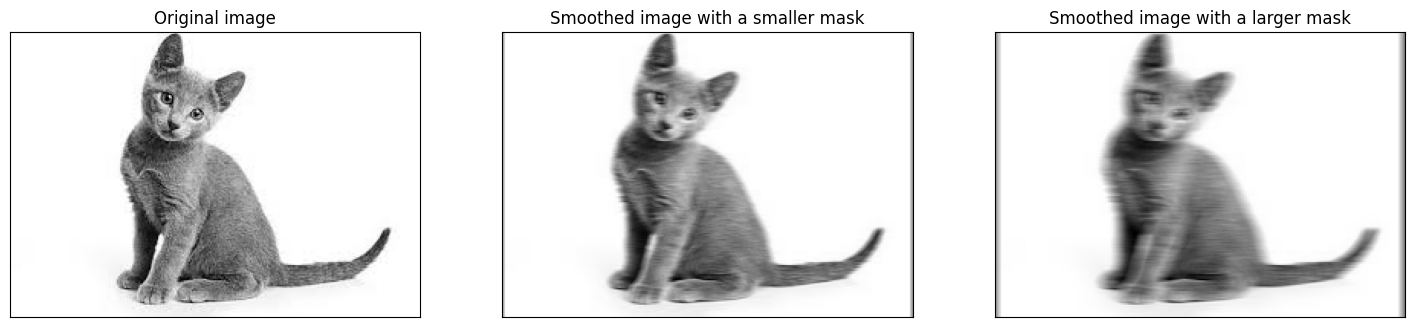

In [33]:
# Define a larger 1 × 10 smoothing mask (kernel).
# Each pixel in the neighborhood has the same weight.
mask = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

# Normalize the mask so that the sum of all weights is equal to 1.
# This ensures that the overall intensity scale is preserved.
mask = mask / np.sum(mask)

# Display the normalized mask.
print(mask)

# Apply the larger smoothing mask to the image.
# mode='constant' means that pixels outside the image boundaries
# are treated as the constant value specified by cval.
cat_smoother = convolve(
    catint,
    mask,
    mode='constant',
    cval=0.0
)

# Create a figure to compare the original image with the
# results obtained using smaller and larger smoothing masks.
fig = plt.figure(figsize=(18, 9))

# Display the original image.
fig.add_subplot(1, 3, 1)
plt.imshow(catint, cmap='gray')
plt.title('Original image')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with the smaller mask.
fig.add_subplot(1, 3, 2)
plt.imshow(cat_smooth, cmap='gray')
plt.title('Smoothed image with a smaller mask')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with the larger mask.
fig.add_subplot(1, 3, 3)
plt.imshow(cat_smoother, cmap='gray')
plt.title('Smoothed image with a larger mask')
plt.xticks([])
plt.yticks([])

plt.show()

### Using a Non-Uniform Mask

A smoothing mask does not need to have equal weights. In this example, we use a **non-uniform 1D mask** that gives more weight to the central pixel. The code normalizes the mask, applies the convolution, and compares the result with a **uniform mask**.


[[0.03846154 0.15384615 0.61538462 0.15384615 0.03846154]]


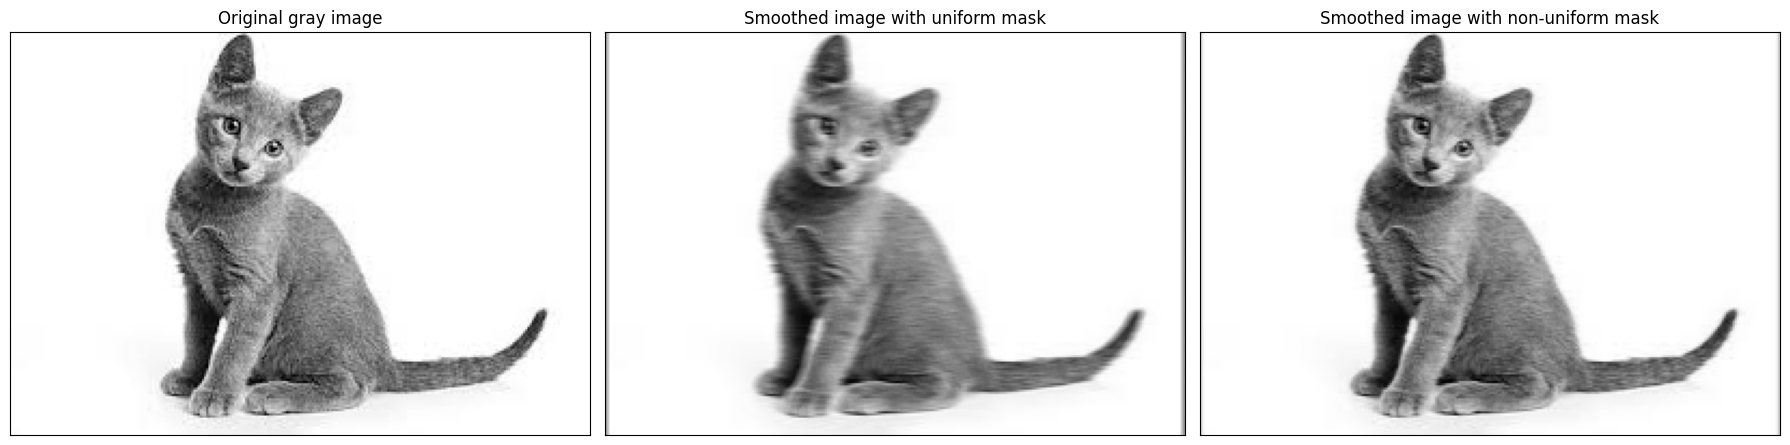

In [34]:
# Define a non-uniform 1D smoothing mask.
# The central pixel has a higher weight than its neighbors.
mask_non_uniform = np.array([[1, 4, 16, 4, 1]])

# Normalize the mask so that the sum of all weights is equal to 1.
# This helps preserve the overall intensity scale of the image.
mask_non_uniform = mask_non_uniform / np.sum(mask_non_uniform)

# Display the normalized mask.
print(mask_non_uniform)

# Apply the non-uniform smoothing mask to the image.
# Pixels outside the image boundaries are treated as 0.
cat_smooth_nonuniform = convolve(
    catint,
    mask_non_uniform,
    mode='constant',
    cval=0.0
)

# Create a figure to compare the different smoothing results.
fig = plt.figure(figsize=(18, 9))

# Display the original image.
fig.add_subplot(1, 3, 1)
plt.imshow(catint, cmap='gray')
plt.title('Original gray image')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with the uniform mask.
fig.add_subplot(1, 3, 2)
plt.imshow(cat_smooth, cmap='gray')
plt.title('Smoothed image with uniform mask')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with the non-uniform mask.
fig.add_subplot(1, 3, 3)
plt.imshow(cat_smooth_nonuniform, cmap='gray')
plt.title('Smoothed image with non-uniform mask')
plt.xticks([])
plt.yticks([])

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

## *Noise*

**What kind of image noise do you know?**

This example demonstrates how to simulate image degradation by adding **Gaussian noise** to an image. First, Gaussian noise with zero mean and a variance of 0.01 is added using the `random_noise()` function from *scikit-image*. The code then inspects the resulting image by printing its data type and pixel value range, and finally displays the original and noisy images side by side to visualize the effect of the added noise.




float64
0.0
1.0


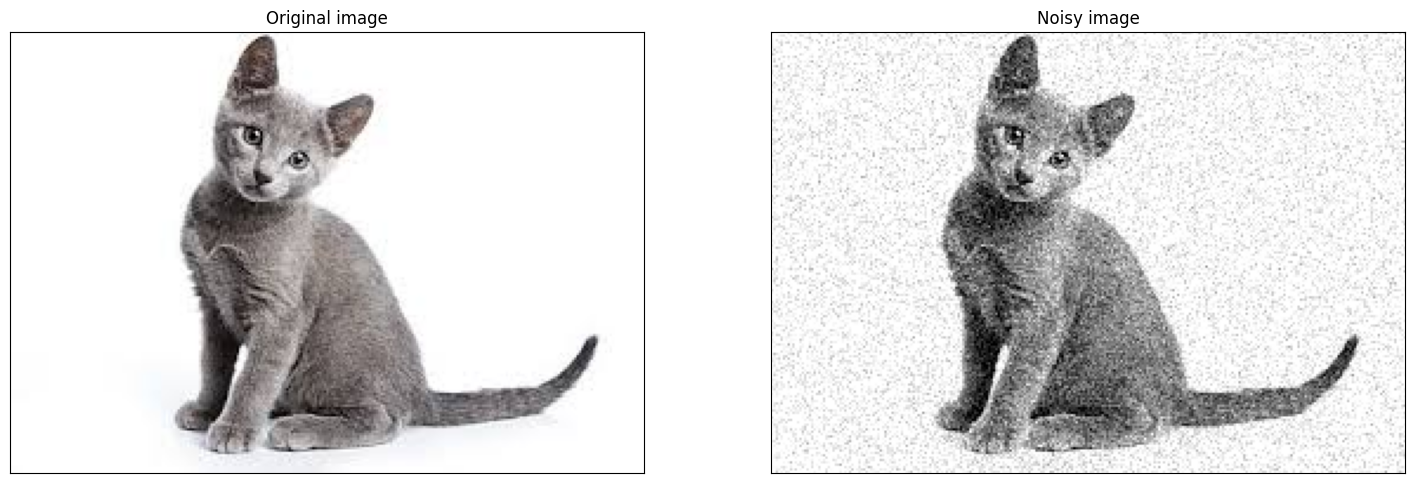

In [35]:
# Import the random_noise function from scikit-image.
# This function is used to add different types of noise to an image.
from skimage.util import random_noise

# Add Gaussian noise to the image 'catint'.
# mean=0   -> noise is centered around 0
# var=0.01 -> variance of the Gaussian noise (controls noise intensity)
cat_noisy = random_noise(catint, mean=0, var=0.01)

# Print the data type of the noisy image.
# random_noise returns a floating-point image with values normalized to [0, 1].
print(cat_noisy.dtype)

# Display the minimum pixel value in the noisy image.
print(cat_noisy.min())

# Display the maximum pixel value in the noisy image.
print(cat_noisy.max())

# Visualize the original and noisy images side by side.
fig = plt.figure(figsize=(18,9))

# First subplot: original image
fig.add_subplot(1,2,1)
plt.imshow(cat, cmap='gray')
plt.title('Original image')
plt.xticks([])   # Remove x-axis ticks
plt.yticks([])   # Remove y-axis ticks

# Second subplot: image with Gaussian noise
fig.add_subplot(1,2,2)
plt.imshow(cat_noisy, cmap='gray')
plt.title('Noisy image')
plt.xticks([])   # Remove x-axis ticks
plt.yticks([])   # Remove y-axis ticks

# Display the figure
plt.show()

### Reducing Noise with Convolution Filters

In the following example, we apply two different smoothing filters to the noisy image using convolution. The first filter uses a **uniform mask**, which assigns equal weights to all neighboring pixels and performs simple averaging. The second filter uses a **non-uniform mask**, which assigns different weights to neighboring pixels, usually giving greater importance to pixels near the center of the mask.

After filtering, the resulting images are displayed side by side to compare how each mask reduces noise and affects the overall appearance of the image.

In [36]:
print(mask)
print(mask_non_uniform)

[[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]
[[0.03846154 0.15384615 0.61538462 0.15384615 0.03846154]]


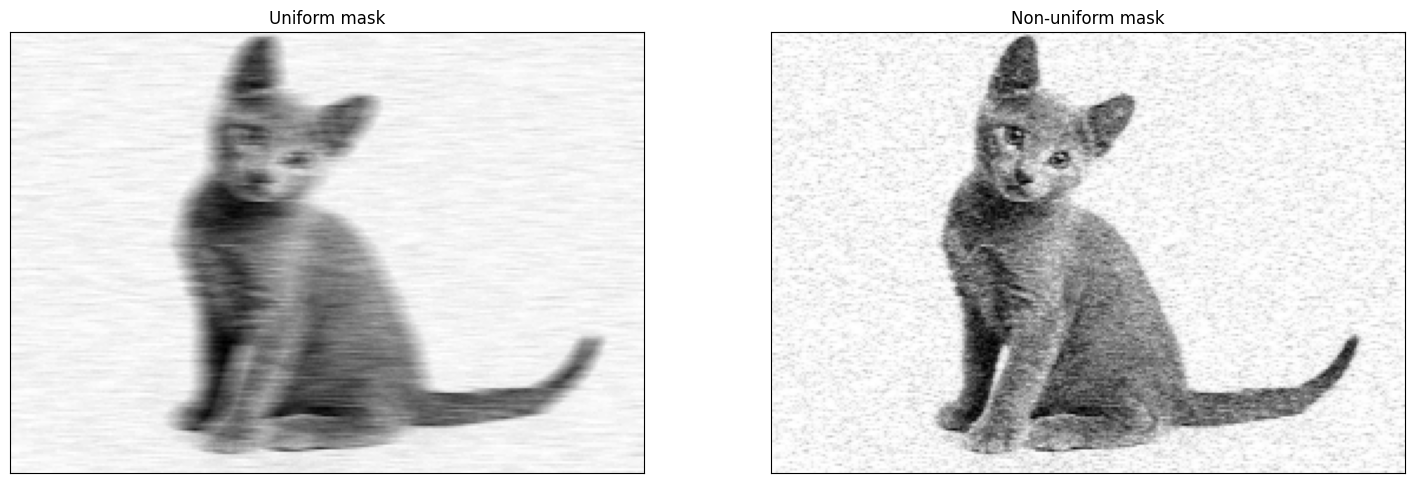

Uniform mask
Minimum value: 0.07791327239598655
Maximum value: 0.9999999999999999

Non-uniform mask
Minimum value: 0.012631941374309914
Maximum value: 1.0


In [37]:
# Apply convolution using the uniform mask.
# This smooths the image by averaging neighboring pixel values.
cat_noisy_smooth = convolve(cat_noisy, mask)

# Apply convolution using the non-uniform mask.
# Neighboring pixels contribute with different weights,
# producing a weighted smoothing effect.
cat_noisy_smooth_nonuniform = convolve(cat_noisy, mask_non_uniform)

# Visualize the filtered images.
fig = plt.figure(figsize=(18,9))

# First subplot: result using the uniform mask
fig.add_subplot(1,2,1)
plt.imshow(cat_noisy_smooth, cmap='gray')
plt.title('Uniform mask')
plt.xticks([])   # Remove x-axis ticks
plt.yticks([])   # Remove y-axis ticks

# Second subplot: result using the non-uniform mask
fig.add_subplot(1,2,2)
plt.imshow(cat_noisy_smooth_nonuniform, cmap='gray')
plt.title('Non-uniform mask')
plt.xticks([])   # Remove x-axis ticks
plt.yticks([])   # Remove y-axis ticks

# Display the figure
plt.show()

# Print the minimum and maximum pixel values after
# filtering with the uniform mask.
print("Uniform mask")
print("Minimum value:", cat_noisy_smooth.min())
print("Maximum value:", cat_noisy_smooth.max())

# Print the minimum and maximum pixel values after
# filtering with the non-uniform mask.
print("\nNon-uniform mask")
print("Minimum value:", cat_noisy_smooth_nonuniform.min())
print("Maximum value:", cat_noisy_smooth_nonuniform.max())

## What is the **Gaussian filter**, and why is it interesting?

The **multi-dimensional Gaussian filter** is available through:

```python
skimage.filters.gaussian(
    image,
    sigma=1,
    output=None,
    mode='nearest',
    cval=0,
    preserve_range=False,
    truncate=4.0
)
```

The function is a wrapper around `scipy.ndimage.gaussian_filter()`.

Some important characteristics of the Gaussian filter are:

* **Integer input images are converted to floating-point values.**
* The output is typically a **floating-point array**. If `output` is not specified, a new array is allocated for the result.
* The multi-dimensional Gaussian filter is implemented as a sequence of **one-dimensional convolution filters**, making the computation more efficient.
* Intermediate results are stored using the output data type. Therefore, using an output type with limited precision can lead to **loss of accuracy** in the intermediate calculations.

The Gaussian filter is particularly interesting because it provides a **smooth, controlled way to reduce noise and image detail**, while the `sigma` parameter controls the amount of smoothing.

> Next, we create an image containing a **single bright pixel** and apply a **Gaussian filter** with `sigma=5`. We then inspect the resulting pixel values and visualize the **Gaussian-shaped intensity distribution**.



Min: 7.8571424976336e-07 Max: 0.0063667085089244325 Type: float64 Shape: (30, 30)


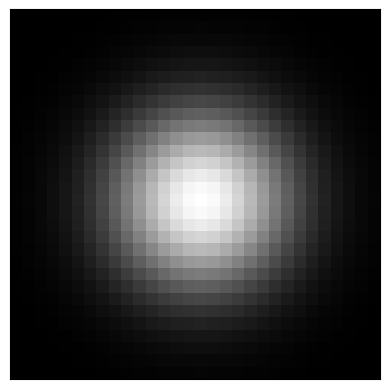

In [38]:
# Import the Gaussian filter from scikit-image.
from skimage.filters import gaussian

# Create a 30 × 30 image initialized with zeros.
a = np.zeros((30, 30))

# Set the central pixel to 1.
# This creates a single bright point in an otherwise black image.
a[15, 15] = 1

# Apply a Gaussian filter with sigma=5.
# The Gaussian filter spreads the intensity of the central pixel
# to its neighboring pixels, creating a smooth Gaussian-shaped spot.
gs = gaussian(a, sigma=5)

# Display the minimum and maximum values, data type, and shape
# of the filtered image.
print(
    'Min:', gs.min(),
    'Max:', gs.max(),
    'Type:', gs.dtype,
    'Shape:', gs.shape
)

# Display the filtered image using a grayscale colormap.
# By default, imshow() automatically scales the intensity range.
plt.imshow(gs, cmap='gray')

# Alternatively, use a fixed intensity range from 0 to 1.
# This allows the same scale to be used when comparing images.
# plt.imshow(gs, cmap='gray', vmin=0, vmax=1)

# Remove the axis ticks for a cleaner visualization.
plt.xticks([])
plt.yticks([])

# Display the image.
plt.show()

> Next, we apply a **Gaussian filter** with `sigma=1.5` to the noisy image. We then compare the result with the image smoothed using the **non-uniform mask**.


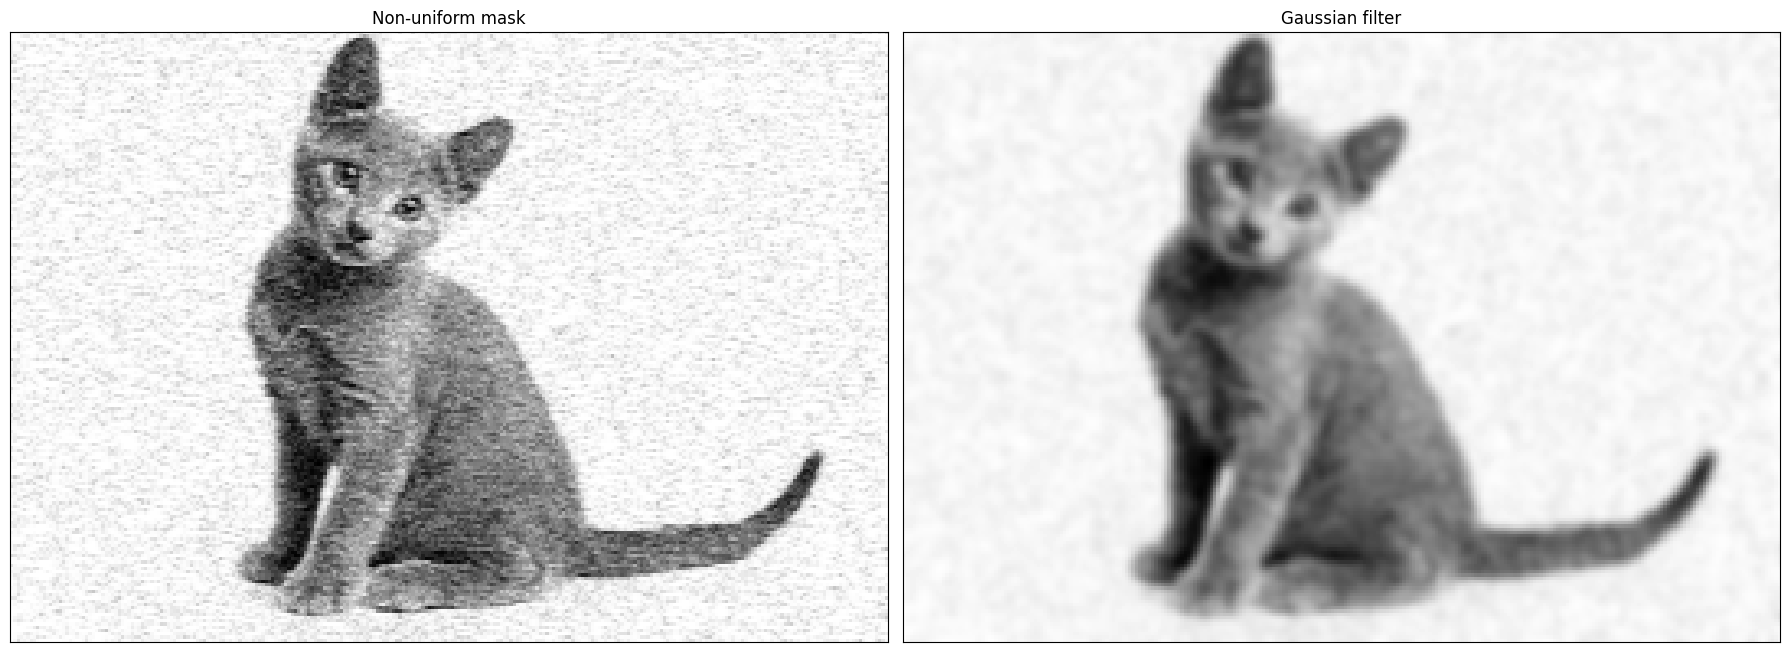

In [39]:
# Apply a Gaussian filter with sigma=1.5 to smooth the noisy image.
cat_noisy_gaussian = gaussian(cat_noisy, sigma=1.5)

# Create a figure to compare the two smoothing methods.
fig = plt.figure(figsize=(18, 8))

# Display the image smoothed with the non-uniform mask.
fig.add_subplot(1, 2, 1)
plt.imshow(cat_noisy_smooth_nonuniform, cmap='gray')
plt.title('Non-uniform mask')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with the Gaussian filter.
fig.add_subplot(1, 2, 2)
plt.imshow(cat_noisy_gaussian, cmap='gray')
plt.title('Gaussian filter')
plt.xticks([])
plt.yticks([])

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

### Effect of Different Sigma Values

Next, we apply the **Gaussian filter** with different values of `sigma` and compare the resulting images. This allows us to observe how increasing `sigma` affects the amount of **smoothing and blur**.

As `sigma` increases, the Gaussian filter produces **stronger smoothing**, reducing more image detail and resulting in a more blurred image.


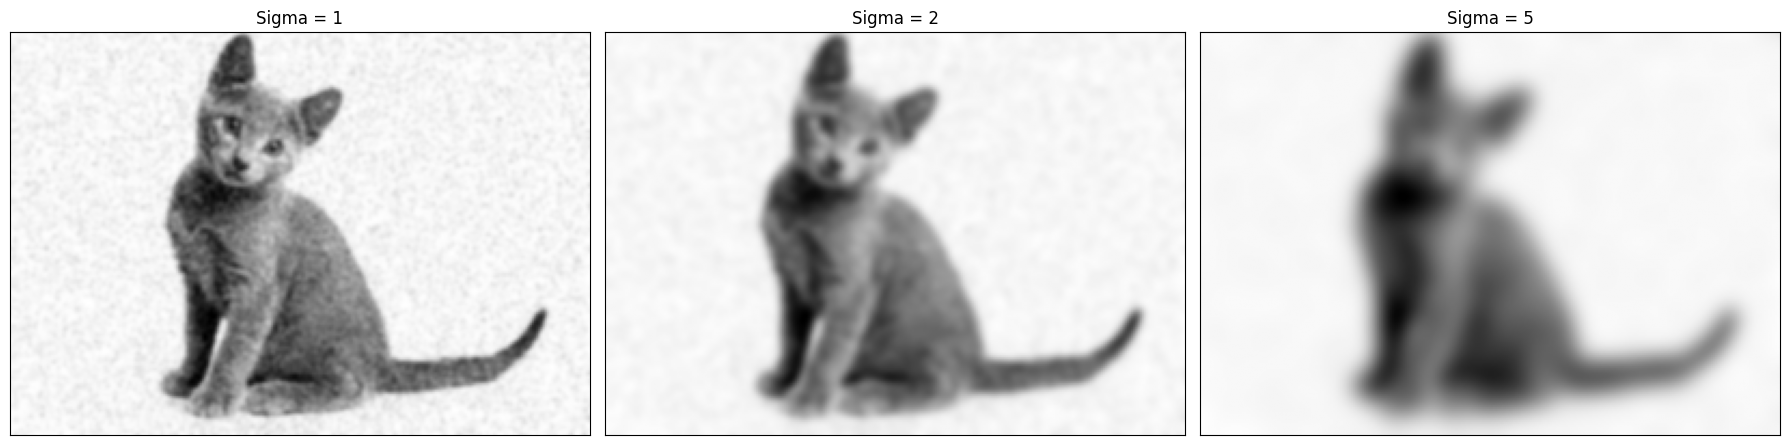

In [40]:
# Apply the Gaussian filter with different sigma values.
# A larger sigma produces stronger smoothing.
cat_noisy_gaussian1 = gaussian(cat_noisy, sigma=1)
cat_noisy_gaussian2 = gaussian(cat_noisy, sigma=2)
cat_noisy_gaussian5 = gaussian(cat_noisy, sigma=5)

# Create a figure to compare the effect of different sigma values.
fig = plt.figure(figsize=(18, 8))

# Display the image smoothed with sigma=1.
fig.add_subplot(1, 3, 1)
plt.imshow(cat_noisy_gaussian1, cmap='gray')
plt.title('Sigma = 1')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with sigma=2.
fig.add_subplot(1, 3, 2)
plt.imshow(cat_noisy_gaussian2, cmap='gray')
plt.title('Sigma = 2')
plt.xticks([])
plt.yticks([])

# Display the image smoothed with sigma=5.
fig.add_subplot(1, 3, 3)
plt.imshow(cat_noisy_gaussian5, cmap='gray')
plt.title('Sigma = 5')
plt.xticks([])
plt.yticks([])

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

### **Median Filter**

Another common smoothing technique is the **median filter**. Unlike the Gaussian filter, which computes a weighted average, the median filter replaces each pixel with the **median value of its neighborhood**.

The median filter is particularly useful for reducing **salt-and-pepper noise** while preserving edges better than simple averaging filters.

> Next, we create a **disk-shaped mask** that will be used as the neighborhood for the median filter. The `radius` parameter controls the size of the disk. We then display the mask to visualize the neighborhood used by the filter.



[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


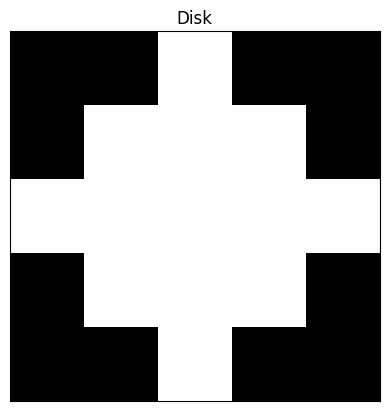

In [41]:
# Import the median filter from scikit-image.
from skimage.filters import median

# Import the disk-shaped structuring element.
from skimage.morphology import disk

# Define the radius of the disk-shaped neighborhood.
radius = 2

# Create and display the disk-shaped mask.
# The radius determines the size of the neighborhood
# used by the median filter.
print(disk(radius))

# Display the disk-shaped mask using a grayscale colormap.
plt.imshow(disk(radius), cmap='gray')

# Add a title to the mask.
plt.title('Disk')

# Remove the axis ticks for a cleaner visualization.
plt.xticks([])
plt.yticks([])

# Display the figure.
plt.show()

> Next, we create a **21 × 21 image** containing a single bright pixel at the center. We then apply the **median filter** using the disk-shaped mask and compare the minimum and maximum values before and after filtering. Finally, we normalize the disk mask so that its values sum to 1.


In [42]:
# Create a 21 × 21 image filled with zeros.
a = np.zeros((21, 21))

# Set the center pixel to 1.
# This creates a single bright pixel in the image.
a[10, 10] = 1

# Display the minimum and maximum values of the original image.
print('Original image:  Min:', a.min(), '\t Max:', a.max())

# Apply the median filter using the disk-shaped mask.
md = median(a, disk(radius))

# Display the minimum and maximum values after median filtering.
print('Median image:    Min:', md.min(), '\t Max:', md.max())

# Create the disk-shaped mask using the previously defined radius.
D = disk(radius)

# Normalize the mask so that the sum of its values is equal to 1.
D = D / D.sum()

Original image:  Min: 0.0 	 Max: 1.0
Median image:    Min: 0.0 	 Max: 0.0


> Next, we apply the normalized disk mask using **convolution** to create a mean-filtered image. We then compare the **original image**, the **median-filtered image**, and the **mean-filtered image** side by side.


Mean image:      Min: 0.0 	 Max: 0.07692307692307693


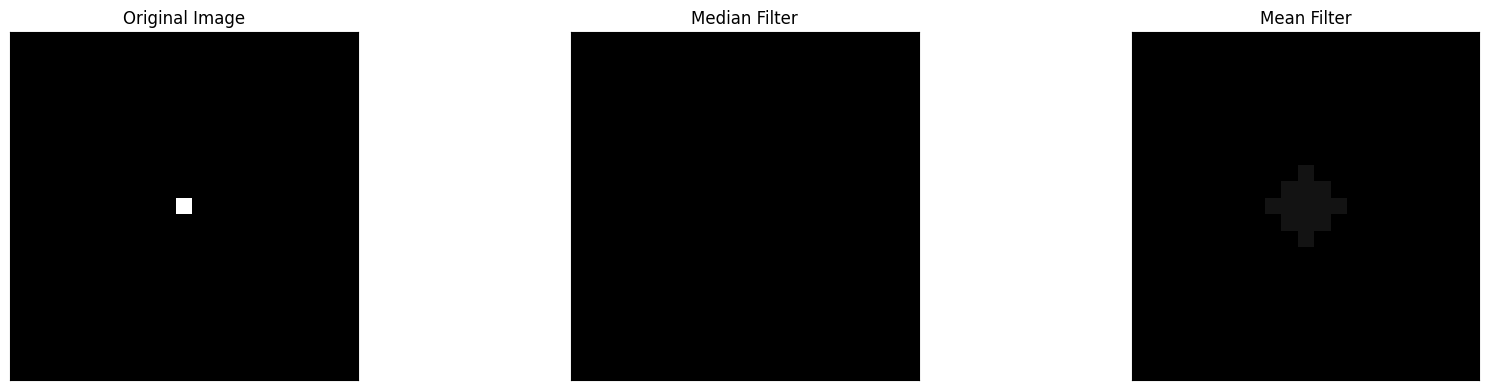

In [43]:
# Apply the normalized disk mask using convolution.
# This produces a mean-filtered image.
mn = convolve(a, D)

# Display the minimum and maximum values of the mean-filtered image.
print('Mean image:      Min:', mn.min(), '\t Max:', mn.max())

# Create a figure to compare the three images.
fig = plt.figure(figsize=(18, 4))

# Display the original image.
fig.add_subplot(1, 3, 1)
plt.imshow(a, cmap='gray')
plt.title('Original Image')
plt.xticks([])
plt.yticks([])

# Display the image after applying the median filter.
# vmin=0 and vmax=1 ensure the same intensity range is used.
fig.add_subplot(1, 3, 2)
plt.imshow(md, cmap='gray', vmin=0, vmax=1)
plt.title('Median Filter')
plt.xticks([])
plt.yticks([])

# Display the image after applying the mean filter.
# vmin=0 and vmax=1 ensure the same intensity range is used.
fig.add_subplot(1, 3, 3)
plt.imshow(mn, cmap='gray', vmin=0, vmax=1)
plt.title('Mean Filter')
plt.xticks([])
plt.yticks([])

# Adjust the spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

### Question

In this example, why does the **median filter remove the bright pixel**?

### Answer

The bright pixel is surrounded by many pixels with a value of **0**. When the median filter examines the neighborhood, most of the values are therefore 0. The **median value is 0**, so the bright pixel is replaced by 0 and disappears from the filtered image.

This illustrates an important property of the **median filter**: it is effective at removing isolated bright or dark pixels while preserving larger structures and edges.


### How do the **median** and **mean** filters affect images with **salt-and-pepper noise**?

> Next, we convert the RGB image to **grayscale** and introduce **salt-and-pepper (impulse) noise** using `random_noise()`. We then print the **mask** and the noisy image properties to compare their data types and dimensions.


In [44]:
# Convert the RGB image to grayscale.
cat = rgb2gray(cat)

# Add salt-and-pepper (impulse) noise to the grayscale image.
cat_noisy_sp = random_noise(cat, mode='salt')

# Display the mask values.
print(mask)

# Display the data type of the mask.
print(mask.dtype)

# Display the data type of the noisy image.
print(cat_noisy_sp.dtype)

# Display the dimensions of the mask.
print(mask.shape)

# Display the dimensions of the noisy image.
print(cat_noisy_sp.shape)

[[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]
float64
float64
(1, 10)
(187, 269)


> Next, we apply the **mean filter** to the salt-and-pepper noisy image using the previously defined normalized mask. The convolution replaces each pixel with a weighted average of its neighboring pixels, helping to reduce the noise.


In [45]:
# Apply the mean filter to the salt-and-pepper noisy image.
# The normalized mask is used to compute the local average
# of neighboring pixels.
cat_noisy_mean = convolve(cat_noisy_sp, mask)

> Next, we apply the **median filter** to the salt-and-pepper noisy image using a disk-shaped neighborhood with a radius of 3. We then display the **noisy image**, the result of the **mean filter**, and the result of the **median filter** side by side to compare how each filter reduces the noise.


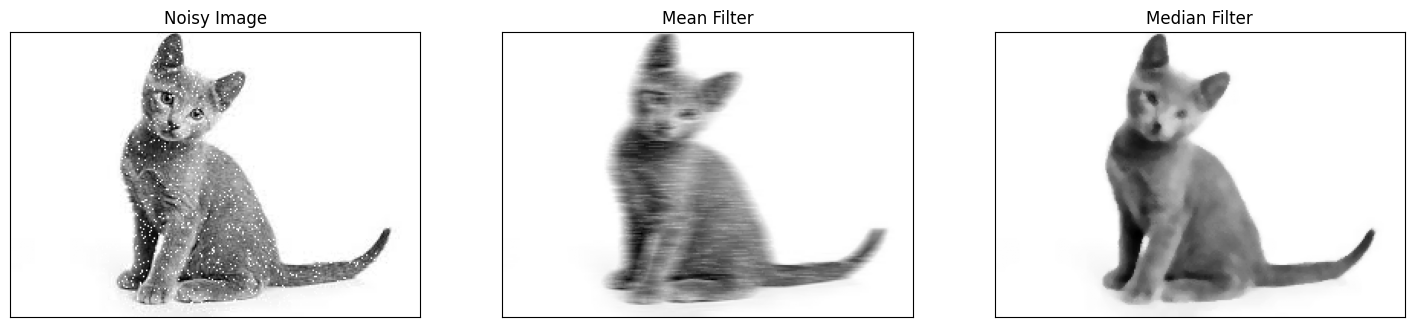

In [46]:
# Apply the median filter to the salt-and-pepper noisy image.
# A disk with radius 3 defines the neighborhood used by the filter.
cat_noisy_median = median(cat_noisy_sp, disk(3))

# Create three plots arranged side by side.
# sharex and sharey ensure that all images use the same axes.
fig, axes = plt.subplots(
    1, 3,
    sharex=True,
    sharey=True,
    figsize=(18, 8)
)

# Display the noisy image, mean-filtered image, and median-filtered image.
for ax, img, title in zip(
    axes,
    [cat_noisy_sp, cat_noisy_mean, cat_noisy_median],
    ['Noisy Image', 'Mean Filter', 'Median Filter']
):
    # Display the image using a grayscale colormap.
    ax.imshow(img, cmap='gray')

    # Add a title to the image.
    ax.set_title(title)

    # Remove the axis ticks for a cleaner visualization.
    ax.set_yticks([])
    ax.set_xticks([])

# Display the figure.
plt.show()

> Next, we introduce **salt-and-pepper noise** into the grayscale image. We then apply both the **mean filter** and the **median filter** to reduce the noise. Finally, we display the noisy image and both filtered results side by side to compare their effects.


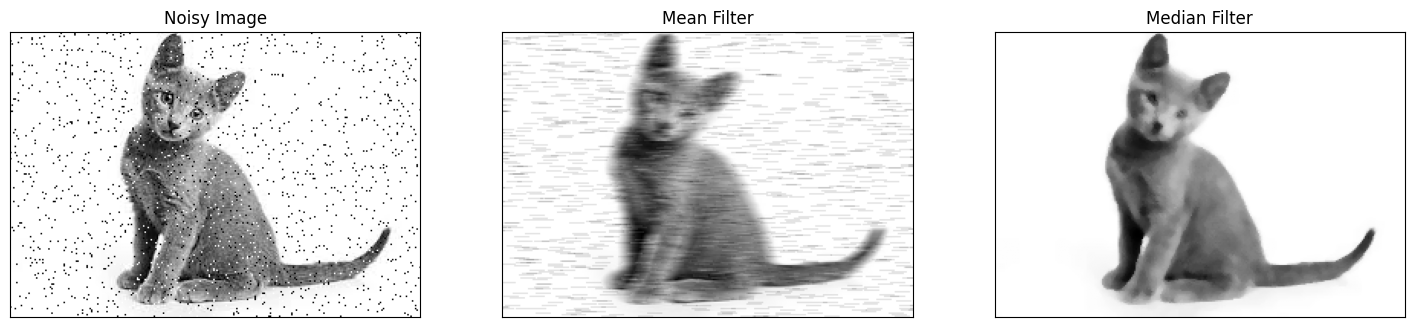

In [47]:
# Add salt-and-pepper noise to the grayscale image.
cat_noisy_sp = random_noise(cat, mode='s&p')

# Apply the mean filter using the previously defined mask.
cat_noisy_mean = convolve(cat_noisy_sp, mask)

# Apply the median filter using a disk-shaped neighborhood with radius 3.
cat_noisy_median = median(cat_noisy_sp, disk(3))

# Create three plots arranged side by side for comparison.
fig, axes = plt.subplots(
    1, 3,
    sharex=True,
    sharey=True,
    figsize=(18, 8)
)

# Display the noisy image and the results of both filters.
for ax, img, title in zip(
    axes,
    [cat_noisy_sp, cat_noisy_mean, cat_noisy_median],
    ['Noisy Image', 'Mean Filter', 'Median Filter']
):
    # Display the image using a grayscale colormap.
    ax.imshow(img, cmap='gray')

    # Add a title to each image.
    ax.set_title(title)

    # Remove the axis ticks for a cleaner visualization.
    ax.set_yticks([])
    ax.set_xticks([])

# Display the figure.
plt.show()

> Next, we compare the effects of three different smoothing methods on the **salt-and-pepper noisy image**: the **mean filter**, **Gaussian filter**, and **median filter**. The four images are displayed side by side to make it easier to compare how each filter reduces the noise and preserves image details.


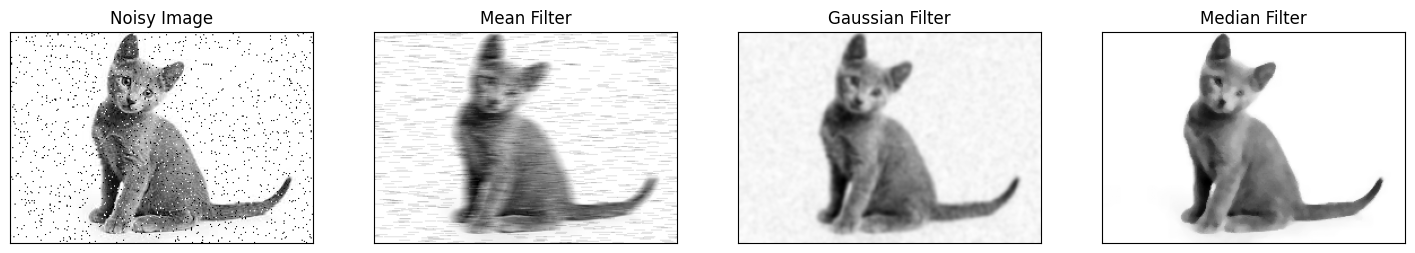

In [48]:
# Create four plots arranged side by side for comparison.
fig, axes = plt.subplots(
    1, 4,
    sharex=True,
    sharey=True,
    figsize=(18, 8)
)

# Display the noisy image and the results of the three filters.
for ax, img, title in zip(
    axes,
    [cat_noisy_sp, cat_noisy_mean, cat_noisy_gaussian, cat_noisy_median],
    ['Noisy Image', 'Mean Filter', 'Gaussian Filter', 'Median Filter']
):
    # Display the image using a grayscale colormap.
    ax.imshow(img, cmap='gray')

    # Add a title to each image.
    ax.set_title(title)

    # Remove the axis ticks for a cleaner visualization.
    ax.set_yticks([])
    ax.set_xticks([])

# Display the figure.
plt.show()